<a href="https://colab.research.google.com/github/PedroIvoLeite/Colab/blob/main/Projeto_Final_Efeito_das_Dietas_no_Descarte_ou_Venda_de_Bovinos_v3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. V3.1 Efeito dos Parâmetros no Descarte de Bovinos na Pecuária de Corte

# 2. Objetivo Geral

Uma fazenda bovina inteligente integra diversas fontes de dados (sensores IoT, APIs de clima, aplicativos de gestão) para alimentar algoritmos de Inteligência Artificial capazes de identificar precocemente quais animais estão prontos para o abate e quais apresentam baixo desempenho, aumentando a eficiência e a rentabilidade do negócio. Esses dados (peso, leite, clima, etc.) são coletados automaticamente no campo e enviados para uma plataforma central na nuvem. Em seguida, uma equipe de dados realiza o processamento (limpeza, organização e análise) e treinamento de modelos de IA.

**A Plataforma Intelicampo**

1.   É uma plataforma operacional para fazendas de corte e leite - pequenas, médias e grandes
1.   Animais são pesados sem interferência humana e os pesos são enviados para o servidor web
1.   É um coletor de dados na primeira fase; na segunda fase será um gerador de informações
2.   Acompanha o peso e a produção de leite de cada animal, dos  piquetes e dos lotes lógicos
1.   **Este projeto tem como objetivo principal pesquisar os métodos estatísticos necessarios para trazer "inteligencia" para o para o projeto Intilicampo**



# 3. Questão de Pesquisa

Maximizar a produtividade de uma propriedade rural requer monitorar indicadores de desempenho zootécnico e indicadores econômicos. Em sistemas de confinamento de engorda (pecuária de corte), cujo objetico primordial é engordar os animais até atingir o peso de 450 kg no menor tempo possivel e gastando o menos possível dos recursos da propriedade rural.

Monitorar indicadores zootécnicos permite avaliar a eficiência produtiva do rebanho e identificar pontos de melhoria no manejo e na nutrição dos animais. Sabendo o momento correto de **descartar** animais do rebanho com baixo desempenho operacional reduz os gastos com animais improdutivos. Alguns destes indicadores são:

* **Ganho Médio Diário (GMD_medio)** – Indica quantos quilos, em média, cada animal ganha por dia no confinamento. É um dos índices mais acompanhados, pois reflete se os animais estão performando conforme o esperado e respondendo bem à dieta. Um GMD elevado significa crescimento mais rápido, reduz o tempo de engorda e aumenta a produção de carne por período. Esse indicador orienta ajustes na alimentação: por exemplo, se o GMD estiver abaixo da meta, pode ser necessário reformular a dieta ou verificar problemas de saúde.
* **Índice de Conversão Alimentar (ICA)** – Mede a eficiência com que os animais convertem alimento em peso corporal. É calculado dividindo-se o consumo de ração pelo ganho de peso no período. Em confinamento, onde a alimentação é o maior custo, um ICA baixo (ou seja, poucos quilos de ração por quilo de ganho) indica alta eficiência alimentar. Melhorar a conversão alimentar – por exemplo, via balanceamento de dieta ou genética – impacta diretamente o custo por kg produzido.

* **Peso Final** - Indicador direto de desempenho absoluto. Baixo peso final pode indicar improdutividade.

* **z_score** - Avalia quão fora da média o animal está (comparado ao lote todo). Valores muito negativos sugerem baixo desempenho.

* **Dietas e Conversão Alimentar** - Custo e capacidade das dietas em ajudar os animais a converterem a alimentação oferecida em peso corporal.

* **Custo Total** - Reflete o custo absoluto de alimentar o animal no período. Deve ser sustentável.

O objetivo dessa pesquisa é, a partir de dataset gerado para um rebanho durante um período de confinamento, identificar aqueles animais com baixo desempenho e sinalizar o produtor rural, contribuindo desta forma diretamente para uma maior produtividade da propriedade rural.

Como não encontrei um dataset específico para pecuária de precisão, a primeira fase deste trabalho foi gerar um dataset para aplicar os métodos estatísticos de análise de dados e testes. Fiz uma pesquisa específica sobre as principais regras de negócio do confinamento de animais em fazendas de corte para gerar os dados para 200 animais durante o período de 60 adias. Procurei faze-lo parametrizado para faze-lo abrangente para vários tamanhos de propriedade rural. Obviamente muitas outras variáveis podem ser acrescentras.

Pretendo disponibilizar este dataset para outros pesquisadores. Em paralelo estou desenvolvendo ferramentas (falta a palavra certa) para coleta de dados em tempo real  em fazendas e gerar uma base de dados mais consistente e confiável.


# 4. Processo Experimental



Etapas para esse processo experimental:
*   Gerar o dataset experimental (**4.1)**;
*   Fazer o delineamento de experimentos**(5)**;
*   Testar hipóteses **(6)**;
*   Analisar os dados e gráficos **(7)**;
*   Fazer testes estatísticos **(7.1)**;
*   Interpretar os resultados **(8)**;



In [ ]:
#===============================================================================
#           Bibliotecas Utilizadas
#===============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import ttest_ind
from scipy.stats import levene
from sklearn.tree import plot_tree
from scipy.stats import f_oneway, mannwhitneyu, shapiro, kruskal
from scipy.stats import pearsonr, spearmanr, zscore
import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# 4.1 Geração do Dataset Animal

Descricao do dataset gerado

     AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio       ICA  \
0           1     C   324.230170  396.798933   1.229979  8.679969   
1           2     A   303.893535  360.429463   0.958236  6.439939   
2           3     C   315.234925  372.183990   0.965238  8.352651   
3           4     C   314.812564  377.680411   1.065557  7.891231   
4           5     A   341.778256  405.123544   1.073649  6.112689   
..        ...   ...          ...         ...        ...       ...   
195       196     B   320.512780  367.481348   0.796077  7.260020   
196       197     C   305.507944  377.770809   1.224794  8.694509   
197       198     C   305.649419  361.433683   0.945496  8.607808   
198       199     B   318.684799  374.214599   0.941183  7.479970   
199       200     A   358.770632  419.352134   1.026805  6.918359   

     ConsumoTotalMS  CustoTotal  CustoPorKgGanho      Receita  MargemBruta  
0        629.894609  629.894609         8.679969  3967.989329  3338.094720  
1        364.0879

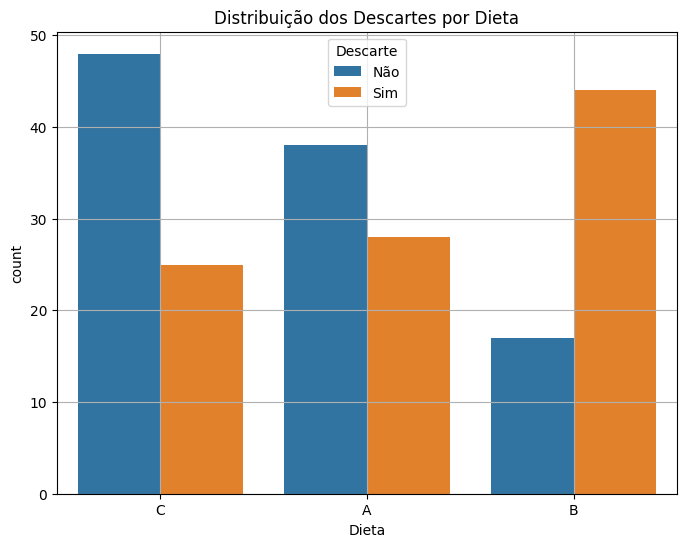

     AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio  Limiar_GMD   z_score  \
0           1     C   324.230170  396.798933   1.229979    0.964092  1.287324   
1           2     A   303.893535  360.429463   0.958236    0.863250 -0.118343   
2           3     C   315.234925  372.183990   0.965238    0.964092 -0.082121   
3           4     C   314.812564  377.680411   1.065557    0.964092  0.436803   
4           5     A   341.778256  405.123544   1.073649    0.863250  0.478663   
..        ...   ...          ...         ...        ...         ...       ...   
195       196     B   320.512780  367.481348   0.796077    0.653858 -0.957154   
196       197     C   305.507944  377.770809   1.224794    0.964092  1.260504   
197       198     C   305.649419  361.433683   0.945496    0.964092 -0.184244   
198       199     B   318.684799  374.214599   0.941183    0.653858 -0.206554   
199       200     A   358.770632  419.352134   1.026805    0.863250  0.236350   

          ICA Descarte  
0 

In [ ]:
# ===============================
#     Simular dados
# ===============================
np.random.seed(42)

num_animais = 200
dias = 60
desvio_gmd = 0.15
desvio_ica = 0.3
desvio_ganho_dia = 0.2
limite_perda_dia = -0.3
ica_minimo = 5.5
peso_descarte = 380

animais = np.arange(1, num_animais + 1)

# 🔧 Atribuir dietas aos animais
dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
dieta_animais = pd.DataFrame({
    'AnimalID': animais,
    'Dieta': dietas
})

# 🔧 Definir parâmetros de ganho médio diário por dieta
ganho_base = {'A': 1.0, 'B': 0.8, 'C': 1.1}
ica_base = {'A': 6.5, 'B': 7.5, 'C': 8.5}

# ===============================
#  Gerar registros diários
# ===============================
registros = []
peso_inicial = np.random.uniform(300, 360, size=num_animais)

for idx, animal in enumerate(animais):
    peso = peso_inicial[idx]
    dieta = dieta_animais.loc[dieta_animais['AnimalID'] == animal, 'Dieta'].values[0]

    gmd_individual = max(np.random.normal(ganho_base[dieta], desvio_gmd), 0)
    ica_individual = max(np.random.normal(ica_base[dieta], desvio_ica), ica_minimo)

    for dia in range(1, dias + 1):
        if dia > 1:
            ganho_dia = max(np.random.normal(gmd_individual, desvio_ganho_dia), limite_perda_dia)
            peso += ganho_dia
        registros.append([
            animal, dia, peso, dieta, gmd_individual, ica_individual
        ])

# ===============================
#  Criar dataframe diário
# ===============================
df = pd.DataFrame(registros, columns=[
    'AnimalID', 'Dia', 'Peso', 'Dieta', 'GMD_individual', 'ICA'
])

# ===============================
#  Agregar dados por animal
# ===============================
peso_final = df.groupby('AnimalID')['Peso'].last()
peso_ini = df.groupby('AnimalID')['Peso'].first()

gmd_medio = (peso_final - peso_ini) / (dias - 1)

# Cálculo do z-score global
media_gmd = gmd_medio.mean()
dp_gmd = gmd_medio.std()

z_score = (gmd_medio - media_gmd) / dp_gmd

# ICA individual (fixo na simulação)
ica_individual = df.groupby('AnimalID')['ICA'].mean()

# ===============================
#  Construir o Dataset
# ===============================
df = pd.DataFrame({
    'AnimalID': animais,
    'Dieta': dietas,
    'PesoInicial': peso_ini.values,
    'PesoFinal': peso_final.values,
    'GMD_medio': gmd_medio.values,
    'z_score': z_score.values,
    'ICA': ica_individual.values
})

# ===============================
#  Calcular média e DP por dieta
# ===============================
estatisticas_dieta = df.groupby('Dieta')['GMD_medio'].agg(['mean', 'std']).reset_index()
estatisticas_dieta.rename(columns={'mean': 'Media_GMD_Dieta', 'std': 'DP_GMD_Dieta'}, inplace=True)

# Merge com o dataframe dos animais
df = df.merge(estatisticas_dieta, on='Dieta', how='left')

# Definir limiar dinâmico de GMD
df['Limiar_GMD'] = df['Media_GMD_Dieta'] - df['DP_GMD_Dieta']

# =================================
#  Definir custo da dieta por tipo
# =================================
custo_dieta = {'A': 1.60, 'B': 1.30, 'C': 1.00}  # custo por kg de matéria seca (exemplo)

# ===============================
#  Adicionar custo da dieta no dataframe dos animais
# ===============================
df['CustoDieta'] = df['Dieta'].map(custo_dieta)

# ============================================
#  Calcular Consumo Total de Matéria Seca (MS)
# ============================================
df['ConsumoTotalMS'] = df['ICA'] * (df['PesoFinal'] - df['PesoInicial'])

# ===============================
# 3. Condições ambientais
# ===============================
temp_dia = {dia: np.random.uniform(15, 35) for dia in range(1, dias + 1)}
umid_dia = {dia: np.random.uniform(50, 90) for dia in range(1, dias + 1)}

# ===============================
#  Calcular Custo Total de Alimentação
# ===============================
df['CustoTotal'] = df['ConsumoTotalMS'] * df['CustoDieta']

# ===============================
#  Custo por kg de peso ganho
# ===============================
#  Fórmula: CustoPorKgGanho = CustoTotal / (PesoFinal - PesoInicial)
df['CustoPorKgGanho'] = df['CustoTotal'] / (df['PesoFinal'] - df['PesoInicial'])

# ===============================
# (Opcional) Calcular Receita e Margem Bruta
# ===============================
#  Exemplo: preço de venda por kg = R$ 10,00
preco_por_kg = 10.00

# Receita do animal (PesoFinal × preço)
df['Receita'] = df['PesoFinal'] * preco_por_kg

#  Margem Bruta = Receita - CustoTotal
df['MargemBruta'] = df['Receita'] - df['CustoTotal']

# ===============================
# 🔍 Verificar resultado
# ===============================
print(df[['AnimalID', 'Dieta', 'PesoInicial', 'PesoFinal', 'GMD_medio',
          'ICA', 'ConsumoTotalMS', 'CustoTotal', 'CustoPorKgGanho',
          'Receita', 'MargemBruta']])

# ===============================
#  Critérios de Descarte
# ===============================
df['Descarte'] = np.where(
    (df['PesoFinal'] < peso_descarte) |
    (df['GMD_medio'] < df['Limiar_GMD']) |
    (df['ICA'] > 9.0) |
    (df['z_score'] < -1),
    'Sim', 'Não'
)

# ===============================
#  Visualizações
# ===============================
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Dieta', hue='Descarte')
plt.title('Distribuição dos Descartes por Dieta')
plt.grid(True)
plt.show()

# ===============================
# 🔍 Verificar tabela final
# ===============================
print(df[['AnimalID', 'Dieta', 'PesoInicial', 'PesoFinal', 'GMD_medio',
                  'Limiar_GMD', 'z_score', 'ICA', 'Descarte']])


In [ ]:
#===============================================================================
#     Dataset Gerado para esse Projeto
#===============================================================================

df

,AnimalID,Dieta,PesoInicial,PesoFinal,GMD_medio,z_score,ICA,Media_GMD_Dieta,DP_GMD_Dieta,Limiar_GMD,CustoDieta,ConsumoTotalMS,CustoTotal,CustoPorKgGanho,Receita,MargemBruta,Descarte
0,1,C,324.230170,396.798933,1.229979,1.287324,8.679969,1.115901,0.151809,0.964092,1.0,629.894609,629.894609,8.679969,3967.989329,3338.094720,Não
1,2,A,303.893535,360.429463,0.958236,-0.118343,6.439939,0.997037,0.133787,0.863250,1.6,364.087901,582.540642,10.303902,3604.294628,3021.753986,Sim
2,3,C,315.234925,372.183990,0.965238,-0.082121,8.352651,1.115901,0.151809,0.964092,1.0,475.675663,475.675663,8.352651,3721.839900,3246.164237,Sim
3,4,C,314.812564,377.680411,1.065557,0.436803,7.891231,1.115901,0.151809,0.964092,1.0,496.104692,496.104692,7.891231,3776.804114,3280.699422,Sim
4,5,A,341.778256,405.123544,1.073649,0.478663,6.112689,0.997037,0.133787,0.863250,1.6,387.210054,619.536086,9.780303,4051.235440,3431.699353,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,B,320.512780,367.481348,0.796077,-0.957154,7.260020,0.802584,0.148726,0.653858,1.3,340.992762,443.290591,9.438027,3674.813478,3231.522887,Sim
196,197,C,305.507944,377.770809,1.224794,1.260504,8.694509,1.115901,0.151809,0.964092,1.0,628.290102,628.290102,8.694509,3777.708095,3149.417993,Sim
197,198,C,305.649419,361.433683,0.945496,-0.184244,8.607808,1.115901,0.151809,0.964092,1.0,480.180237,480.180237,8.607808,3614.336834,3134.156596,Sim
198,199,B,318.684799,374.214599,0.941183,-0.206554,7.479970,0.802584,0.148726,0.653858,1.3,415.361253,539.969629,9.723961,3742.145989,3202.176360,Sim


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AnimalID         200 non-null    int64  
 1   Dieta            200 non-null    object 
 2   PesoInicial      200 non-null    float64
 3   PesoFinal        200 non-null    float64
 4   GMD_medio        200 non-null    float64
 5   z_score          200 non-null    float64
 6   ICA              200 non-null    float64
 7   Media_GMD_Dieta  200 non-null    float64
 8   DP_GMD_Dieta     200 non-null    float64
 9   Limiar_GMD       200 non-null    float64
 10  CustoDieta       200 non-null    float64
 11  ConsumoTotalMS   200 non-null    float64
 12  CustoTotal       200 non-null    float64
 13  CustoPorKgGanho  200 non-null    float64
 14  Receita          200 non-null    float64
 15  MargemBruta      200 non-null    float64
 16  Descarte         200 non-null    object 
dtypes: float64(14), 

# 4.2 Dicionário dos Dados e Variáveis
| Coluna                     | Descrição                                                                 |
|---------------------------|---------------------------------------------------------------------------|
| `Animal ID`               | Identificação unica do Animal (RFID)
| `PesoInicial`          | Peso do animal no início do ciclo        |
 `PesoFinal`          | Peso no final do ciclo         |
| `GMD_medio` | Ganho de peso diário        |
| `z_score`             | Desempenho relativo dentro da população                 |
| `ICA`          | Índice de Conversão Alimentar              |
| `CustoDieta` |Custo da dieta associada                |
| `ConsumoTotalMS`           | Consumo total de matéria seca              |
| `CustoTotal`  | Custo total de alimentação no ciclo                  |
| `Media_GMD_Dieta`          | Desvio padrão de Média de GMD da dieta do animal        |
| `Limiar_GMD` | Limiar mínimo aceitável de GMD (Média - DP)    
| `MargemBruta`             |Receita - Custo Dieta            
| `Descarte`             | Variável-alvo em modelos de classificação para descarte de animal                 |

In [ ]:
# Como indicativo para outros testes, define-se as colunas categóricas, numéricas (Variáveis de análise obrigratórias) e de interesse

categorical_columns = ["Descarte"]
numerical_columns = ["PesoFinal", "PesoInicial","GMD_medio","z_score","ICA","CustoTotal","CustoPorKgGanho","Limiar_GMD","MargemBruta", "ConsumoTotalMS", "CustoDieta","Receita"]

variaveis_de_interesse = ['PesoInicial', 'PesoFinal', 'GMD_medio','ICA','ConsumoTotalMS',
                           'CustoDieta','CustoPorKgGanho','CustoTotal','z_score', 'Receita','MargemBruta']

# 4.3 Matriz de Correlação

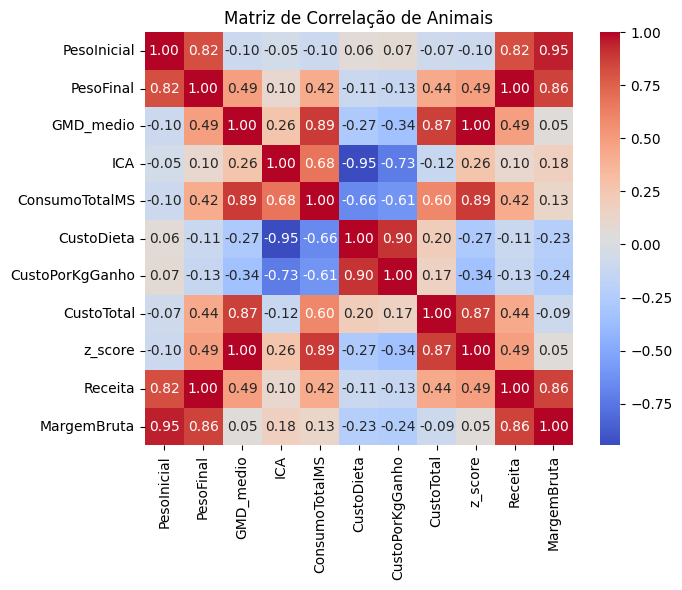

In [ ]:
# ===============================================================================
#     A Matriz de Correlação
# ==============================================================================

corr = df[variaveis_de_interesse].corr()

plt.figure(figsize=(7,6))  # Define o tamanho do gráfico
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação de Animais')
plt.tight_layout()
plt.show()

<table>
  <tr>
    <th>Variável</th>
    <th>Correlação Importante</th>
    <th>Interpretaçã Prática</th>
  </tr>
  <tr>
    <td>GMD_medio x ConsumoTotalMS</td>
    <td>+0.89 </td>
    <td>Forte correlação positiva, Animais que ganham mais peso consomem mais matéria seca</td>
</td>
  <tr>
    <td>GMD_medio x CustoTotal</td>
    <td>+0.87</td>
    <td>Quanto maior o GMD_medio, maior o custo total de alimentação — coerente, já que o consumo aumenta</td>
  </tr>
  <tr>
    <td>GMD_medio x z_score</td>
    <td>+1.00</td>
    <td>Esperado, pois o z_score foi derivado diretamente do GMD.</td>
  </tr>
  <tr>
    <td>ICA X CustoPorKgGanho </td>
    <td>-0.73</td>
    <td> Altamente correlacionado: quanto pior a conversão (maior ICA), mais caro fica cada kg ganho.</td>
  </tr>
  <tr>
    <td>ICA x CustoTotal</td>
    <td>+0.44</td>
    <td>Conversão ineficiente tende a gerar custos mais altos.</td>
  </tr>
  <tr>
    <td>CustoPorKgGanho x ICA </td>
    <td>-0.73</td>
    <td> Altamente correlacionado: quanto pior a conversão (maior ICA), mais caro fica cada kg ganho</td>
  </tr>
  <tr>
    <td> CustoPorKgGanho x CustoDieta  </td>
    <td>+0.90</td>
    <td>Dietas mais caras tornam o custo por kg ganho muito mais elevado.</td>
  </tr>
  <tr>
    <td>CustoPorKgGanho x ConsumoTotalMS</td>
    <td>-0.61</td>
    <td>nversamente proporcional: quem consome mais (com boa eficiência) tende a reduzir o custo por kg.</td>
  </tr>
  <tr>
    <td>PesoInicial x PesoFinal</td>
    <td>+0.82</td>
    <td>Forte correlação, como esperado.</td>
  </tr>
    <td>PesoInicial x Receita</td>
    <td>+0.82</td>
    <td>Animais mais pesados geram maior receita final</td>
  </tr>
    <td>PesoInicial x MargemBruta</td>
    <td>+0.95</td>
    <td>Altamente correlacionado: peso inicial é um dos principais determinantes da margem.\</td>
  </tr>
    <td>CustoDieta x ICA</td>
    <td>-0.95</td>
    <td>Fortemente negativa: dietas mais baratas (como a C) têm ICA mais elevado, indicando conversão pior.</td>
  </tr>
    <td>CustoDieta x CustoPorKgGanho</td>
    <td>+0.90</td>
    <td>Quanto mais cara a dieta, maior o custo por kg de ganho.</td>
  </tr>
    <td>CustoDieta xConsumoTotalMS</td>
    <td>-0.66</td>
    <td>Dietas mais caras estão associadas a menores consumos totais, talvez pela relação inversa com ICA.\</td>
  </tr>
    <td>Receita x PesoFinal</td>
    <td>+1.00</td>
    <td>Receita é diretamente proporcional ao peso final do animal (receita = peso × preço).</td>
  </tr>
    <td>Receita x MargemBruta</td>
    <td>+0.86</td>
    <td>Mais receita geralmente significa margem maior, desde que os custos não superem esse ganho.\</td>
  </tr>
    <td>MargemBruta x PesoInicial</td>
    <td>+0.95</td>
    <td>Quanto mais gordo o animal maior a margem de lucro</td>
  </tr>
    <td>MargemBruta x Receita</td>
    <td>+0.86</td>
    <td>Receita é diretamente proporcional ao peso final do animal (receita = peso × preço).</td>
  </tr>
    <td>MargemBruta x CustoTotalk</td>
    <td>-0.09</td>
    <td>A margem está mais ligada à receita (peso final) do que ao custo direto.\</td>
</table>


**Interpretaçãdas principais correlações**
*   GMD_medio vs PesoFinal (**r ≈ 0.49**):Animais com maior GMD tendem a ter maior peso final — esperado e desejável.
*   GMD_medio vs ICA (**r ≈ 0.26**):Animais com maior GMD geralmente consomem mais — mas como a correlação é fraca, há variabilidade na eficiência.
*   GMD_medio vs CustoPorKgGanho (**r ≈ -0.34**): Quanto maior o GMD, menor o custo por kg de peso ganho — ou seja, melhor desempenho → mais eficiência econômica.
*   ICA vs CustoPorKgGanho (**r ≈ 0.90**): Índice de conversão alimentar alto (menos eficiente) leva a custo mais alto por kg ganho — esperado e crítico para decisões.
*   PesoFinal vs Receita (**r ≈ 1.00**): A receita depende diretamente do peso final (preço × peso), como esperado.
*   CustoTotal vs Receita (**r ≈ 0.86**): Quem ganha mais peso consome mais e gera mais custo — mas isso também aumenta a receita.
*   CustoDieta vs ICA (**r ≈ -0.95**): Dietas mais caras (como a A) tendem a ter animais mais eficientes (menor ICA) — possível reflexo de melhor qualidade nutricional.
*   CustoDieta vs CustoPorKgGanho (**r ≈ -0.73**): Apesar de mais cara, a dieta pode compensar pelo melhor desempenho, reduzindo o custo por kg ganho.
*   MargemBruta vs CustoTotal (**r ≈ -0.24**): A margem depende não só do custo, mas principalmente da relação entre receita e eficiência.
*   GMD_medio vs z_score (**r ≈ 1.00**): O z-score foi derivado do GMD, então a correlação é perfeita.

**Conclusões Práticas**

*   **GMD é o indicador central de desempenho zootécnico.**
*   **ICA e CustoPorKgGanho** são cruciais para avaliar a eficiência alimentar.
*   **Dietas** mais caras parecem promover melhor desempenho e eficiência, o que compensa o custo.
*   A **receita** aumenta com o peso final, mas não necessariamente com eficiência econômica.
*   **Descarte** (variável alvo) de animais deve considerar GMD, ICA e eficiência econômica (CustoPorKgGanho e MargemBruta), não apenas peso.



# 4.4 O Dataset Animal

In [ ]:
#===============================================================================
#       O Dataframe de Animais
#===============================================================================
df

,AnimalID,Dieta,PesoInicial,PesoFinal,GMD_medio,z_score,ICA,Media_GMD_Dieta,DP_GMD_Dieta,Limiar_GMD,CustoDieta,ConsumoTotalMS,CustoTotal,CustoPorKgGanho,Receita,MargemBruta,Descarte
0,1,C,324.230170,396.798933,1.229979,1.287324,8.679969,1.115901,0.151809,0.964092,1.0,629.894609,629.894609,8.679969,3967.989329,3338.094720,Não
1,2,A,303.893535,360.429463,0.958236,-0.118343,6.439939,0.997037,0.133787,0.863250,1.6,364.087901,582.540642,10.303902,3604.294628,3021.753986,Sim
2,3,C,315.234925,372.183990,0.965238,-0.082121,8.352651,1.115901,0.151809,0.964092,1.0,475.675663,475.675663,8.352651,3721.839900,3246.164237,Sim
3,4,C,314.812564,377.680411,1.065557,0.436803,7.891231,1.115901,0.151809,0.964092,1.0,496.104692,496.104692,7.891231,3776.804114,3280.699422,Sim
4,5,A,341.778256,405.123544,1.073649,0.478663,6.112689,0.997037,0.133787,0.863250,1.6,387.210054,619.536086,9.780303,4051.235440,3431.699353,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,B,320.512780,367.481348,0.796077,-0.957154,7.260020,0.802584,0.148726,0.653858,1.3,340.992762,443.290591,9.438027,3674.813478,3231.522887,Sim
196,197,C,305.507944,377.770809,1.224794,1.260504,8.694509,1.115901,0.151809,0.964092,1.0,628.290102,628.290102,8.694509,3777.708095,3149.417993,Sim
197,198,C,305.649419,361.433683,0.945496,-0.184244,8.607808,1.115901,0.151809,0.964092,1.0,480.180237,480.180237,8.607808,3614.336834,3134.156596,Sim
198,199,B,318.684799,374.214599,0.941183,-0.206554,7.479970,0.802584,0.148726,0.653858,1.3,415.361253,539.969629,9.723961,3742.145989,3202.176360,Sim


In [ ]:
# Exportar o dataset .CSV no arquivo local
df.to_csv("Dataset_Bovinos_de_Corte.csv", index=False)
print("Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!")

Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!


# 5. Delineamento de Experimentos (DOE)

In [ ]:
#====================================================================================
#   Teste de Shapiro-Wilk (Normalidade dos Resíduos)
#   W: quanto mais próximo de 1, mais próxima de uma distribuição normal
#   p-valor: probabiliodade de obter os dados observados  p > 0.05  -> não rejeita H0
#                                                         p<= 0.05  -> rejeita H0
#====================================================================================

from scipy.stats import shapiro

# Agrupar os dados por dieta
grupos_dieta = df.groupby('Dieta')['GMD_medio']

# Aplicar o teste de Shapiro-Wilk para cada grupo
for dieta, grupo in grupos_dieta:
    stat, p_valor = shapiro(grupo)
    print(f"Dieta {dieta}:")
    print(f"  Estatística do teste (W) = {stat:.4f}")
    print(f"  p-valor = {p_valor:.4f}")
    if p_valor > 0.05:
        print("  ✅ Distribuição normal (não rejeita H0)\n")
    else:
        print("  ❌ Distribuição NÃO normal (rejeita H0)\n")


Dieta A:
  Estatística do teste (W) = 0.9721
  p-valor = 0.1424
  ✅ Distribuição normal (não rejeita H0)

Dieta B:
  Estatística do teste (W) = 0.9780
  p-valor = 0.3382
  ✅ Distribuição normal (não rejeita H0)

Dieta C:
  Estatística do teste (W) = 0.9775
  p-valor = 0.2166
  ✅ Distribuição normal (não rejeita H0)





**Passo 1 - Objetivo**: *Avaliar o efeito das **dietas (A, B, C)** sobre o **Ganho Médio de Peso Diário (GMD_medio), Indice de Conversão Alimentar (ICA) e Custo Por Quilo  Ganho (CustoPorKgGanho)**.* - conforme indicado pela matriz de correlação

**Passo 2 - Fator**: Tipo de Dieta A, B ou C

**Passo 3 - Variáveis de Resposta**: GMD_medio, ICA, CustoPorKgGanho

**Passo 4 - Tipo de DOE**: Delineamente Inteiramente Casualizado (DIC)

**Passo 5 - Simular Dataset**: Simular os dados para 30 dias.

**Passo 6 - Executar os testes para definir a viabilidade do teste ANOVA**

1.   Independencia das observações: os animais estão em piquetes diferentes ✅
2.   Normalidade dos Resíduos: Teste de Shapiro-Wilk: requisito para o ANOVA ✅
3.   Homogeneidade de variâncias (Levene): requisito para o ANOVA ✅
4.   Análise de Variância (ANOVA) → Verificar se as dietas afetam GMD, ICA, Custo.

**Commentarios**


*   Todas as dietas estão com o p-value >  0.05, distribuição normal
*   Nos três grupos de dietas (A,B,C) as variâncias do GMD são semelhantes
*   Como as três condições foram atendidas, podemos efetuar o teste ANOVA. Foi escolido o teste ANOVA porque temos três grupos de dieta.

In [ ]:
#======================================================
# Teste de Levene (Homogeneidade das Variâncias)
#   Testa dois ou mais grupos para determinar se têm
#  variâncias iguais.
#   H0: as populacoes têm variâncias iguais
#   H1: pelo menos uma população tem variância diferente
#=====================================================

# Separa os grupos de GMD por dieta

grupo_A = df[df['Dieta'] == 'A']['GMD_medio']
grupo_B = df[df['Dieta'] == 'B']['GMD_medio']
grupo_C = df[df['Dieta'] == 'C']['GMD_medio']

# Aplica o teste de Levene
stat_levene, p_levene = levene(grupo_A, grupo_B, grupo_C)

print(f"Estatística de Levene: {stat_levene:.4f}")
print(f"p-valor: {p_levene:.4f}")

# Interpretação simples
if p_levene > 0.05:
    print("✅ As variâncias são homogêneas e não rejeita H0")
else:
    print("❌ As variâncias são diferentes e rejeita H0")


Estatística de Levene: 0.8225
p-valor: 0.4408
✅ As variâncias são homogêneas e não rejeita H0


In [ ]:
#=================================================================================================
#             Teste ANOVA
#   Esse teste verifica se há diferença significativa
#   entre as médias de GMD (Ganho Médio Diário)
#   e entre diferentes dietas (A, B, C).
#
#   F: razão entre a variância entre os grupos e a variância dentro dos grupos.
#       Um valor F alto sugere diferença entre grupos.
#   Sum SQ: Sum Sq do Grupo: diferença entre as médias dos grupos
#           Sum SQ residual:  variância interna dos grupos
#   df (grau de liberdade): grupo = # de grupos - 1
#                           residual = no. de observações - no. de grupos
#         - Quanto maior a Sum Sq do grupo em relação à residual, mais diferentes são os grupos.
#   PR(>F) (p-valor): p <= 0.05 -> rejeita H0, há diferenças entre os grupos
#                     p > 0.05 -> não há evidências de diferença
#================================================================================================


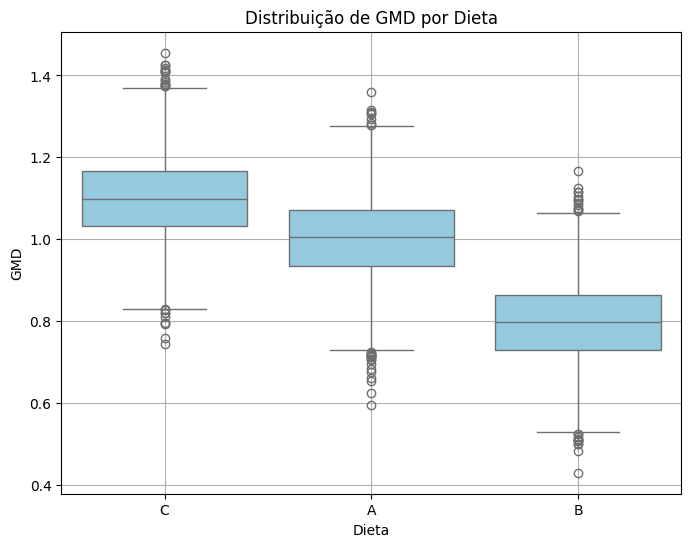

,sum_sq,df,F,PR(>F)
C(Dieta),187.398635,2.0,9205.215322,0.0
Residual,122.116721,11997.0,NaN,NaN


In [ ]:
#===============================================================================
#     Simular Dados de Exemplo (Sampling Data)
#===============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

np.random.seed(42)

n = 60                    # Tamanho da amostra
num_animais = 200         # Define o numero de animais

dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
dados = []

# Array de simulação de valores aleatórios da variável (media, desvio padrão,amostra)

for dieta in dietas:
    if dieta == 'A':
        gmd = np.random.normal(1.0, 0.1, n)
    elif dieta == 'B':
        gmd = np.random.normal(0.8, 0.1, n)
    else:
        gmd = np.random.normal(1.1, 0.1, n)
    for valor in gmd:
        dados.append({'Dieta': dieta, 'GMD': valor})

ds = pd.DataFrame(dados)
ds.head()

# Visualização
plt.figure(figsize=(8,6))
sns.boxplot(x='Dieta', y='GMD', data=ds, color='skyblue')
plt.title('Distribuição de GMD por Dieta')
plt.grid(True)
plt.show()

# ANOVA com Statsmodels
modelo = ols('GMD ~ C(Dieta)', data=ds).fit()
anova_resultado = sm.stats.anova_lm(modelo, typ=2)
anova_resultado

**Interpretação do teste ANOVA**

*   F = 9205.22: Um valor tão alto sugere fortes diferenças entre os grupos.

*   p-valor = 0.0: O valor praticamente zero indica que há diferença significativa entre as dietas


*   O teste ANOVA não diz quais grupos são diferentes. Para isso, usamos um teste pós-hoc, como o Tukey HSD, para identificar quais pares de grupos que diferem.



In [ ]:
#=========================================================================================
#     Teste Tukey HSD (para indicar qual dieta é diferente)
#     É um teste post hoc usado após a realização de um ANOVA com resultado significativo.
#     Seu principal objetivo é:dentificar quais pares de grupos (ex: dietas A, B e C)
#     possuem diferenças estatisticamente significativas entre suas médias.
#=========================================================================================

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df['GMD_medio'], df['Dieta'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B  -0.1945   0.0 -0.2553 -0.1336   True
     A      C   0.1189   0.0  0.0606  0.1771   True
     B      C   0.3133   0.0  0.2539  0.3728   True
---------------------------------------------------



*  A média de GMD da dieta A é maior que B em cerca de **0.19** kg/dia. Como o p-valor é 0.0, essa diferença é estatisticamente significativa, ou seja, a dieta A é superior à dieta B em termos de ganho médio diário. Como o p-valor é < 0.05 a diferença é estatisticamente significativa.

*   A x C: A média de GMD da dieta C é maior que A em cerca de **0.12** kg/dia, a diferença também estatisticamente significativa.

*   B x C: A dieta C é muito superior à dieta B em GMD, com diferença de **0.31** kg/dia, também estatisticamente significativa

*   A ordem de desempenho em GMD é: **Dieta C > Dieta A > Dieta B**, isso reforça que **a dieta C** promove maior desempenho animal em comparação com as demais.

*   **Justifica adoção preferencial da dieta C.**



# 6. Teste de Hipóteses

Vamos fazer os teste de hipoteses entre grupo "**descarte**" e "**nao-descarte**" considerando as variáveis **GMD_medio, ICA e CustoTotal** para validar estatisticamente o critério de descarte. Desta forma fazemos testes diferentes daquele do Delineamento de Experimentos acima. Serão dois grupos e portanto portanto poderemos utilizar o test **t-student**.

**Passo 1** - **Que teste utilizar?**

*   **t-test**: Comparar 2 grupos apenas (Descarte **x** Não-Descarte)

**Passo 2 -  Requisitos para o t-test**

*   Normalidade dos resíduos em cada grupo → Teste de Shapiro-Wilk ✅
*   Homogeneidade de variâncias → Teste de Levene ✅
*  Independência das observações: garantida pelo desenho experimental (um animal não influencia outro. ✅

**Passo 3 - Formulação das hipótese H0 e H1**

**Ganho Medio de Peso Diário (GMD_medio)**
*   **Hipótese Nula (𝐻0)**: O GMD_medio é a mesma entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um GMD_medio é diferente: H1 ​: μi dif μj para algum i dif j

**Indice de Conversão Alimentar (ICA)**
*   **Hipótese Nula (𝐻0)**: O (ICA) é a mesma entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um ICA é diferente: H1 ​: μi dif μj para algum i dif j

**Custo Total (CustoTotal)**
*   **Hipótese Nula (𝐻0)**: O CustoTotal é omesmo entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um CustoTotal é diferente: H1 ​: μi dif μj para algum i dif j

**Passo 4 - Separar os Grupos**: Aplicar o teste de comparações múltiplas de Tukey HSD para identificar quais pares de dietas são significativamente diferentes.

**Passo 5 - Verificar os requisitos para o t-test**

**Passo 6 - Executar o t-test**

In [ ]:
#===============================================================================
#                 Teste Shapiro-Wilky
#===============================================================================

# Separar os grupos (Descarte e não descarte)

grupo_sim = df[df['Descarte'] == 'Sim']
grupo_nao = df[df['Descarte'] == 'Não']

#===============================================================================
#         Variaveis para os testes de hipoteses
#===============================================================================
variaveis = ['GMD_medio', 'ICA', 'CustoTotal']

shapiro_results = []

for var in variaveis:
    dados_sim = grupo_sim[var].dropna()
    dados_nao = grupo_nao[var].dropna()

    if len(dados_sim) >= 3:
        stat_sim, p_sim = shapiro(dados_sim)
    else:
        stat_sim, p_sim = (None, None)

    if len(dados_nao) >= 3:
        stat_nao, p_nao = shapiro(dados_nao)
    else:
        stat_nao, p_nao = (None, None)

    shapiro_results.append({
        'Variável': var,
        'Grupo': 'Descarte = Sim',
        'N': len(dados_sim),
        'W': round(stat_sim, 4) if stat_sim is not None else '—',
        'p-valor': round(p_sim, 5) if p_sim is not None else '—',
        'Normal?': 'Sim' if p_sim is not None and p_sim > 0.05 else 'Não'
    })

    shapiro_results.append({
        'Variável': var,
        'Grupo': 'Descarte = Não',
        'N': len(dados_nao),
        'W': round(stat_nao, 4) if stat_nao is not None else '—', # Fixed typo here (stat_naa -> stat_nao)
        'p-valor': round(p_nao, 5) if p_nao is not None else '—',
        'Normal?': 'Sim' if p_nao is not None and p_nao > 0.05 else 'Não'
    })

df_shapiro = pd.DataFrame(shapiro_results)
display(df_shapiro)

,Variável,Grupo,N,W,p-valor,Normal?
0,GMD_medio,Descarte = Sim,97,0.9847,0.32198,Sim
1,GMD_medio,Descarte = Não,103,0.9726,0.03083,Não
2,ICA,Descarte = Sim,97,0.9543,0.00197,Não
3,ICA,Descarte = Não,103,0.9036,0.00000,Não
4,CustoTotal,Descarte = Sim,97,0.9924,0.86185,Sim
5,CustoTotal,Descarte = Não,103,0.9860,0.35368,Sim


In [ ]:
# Reload the original dataframe from the saved CSV
df = pd.read_csv("Dataset_Bovinos_de_Corte.csv")

In [ ]:
# Teste de homogeneidade de variâncias (Levene)

for var in variaveis:
    stat, p = levene(grupo_sim[var], grupo_nao[var])
    print(f"\n Levene para {var}: stat={stat:.3f}, p={p:.4f}")


 Levene para GMD_medio: stat=5.710, p=0.0178

 Levene para ICA: stat=9.031, p=0.0030

 Levene para CustoTotal: stat=4.014, p=0.0465


<table>
  <tr>
    <th>Variável</th>
    <th>Estatística F</th>
    <th>p-valor</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>GMD_medio</td>
    <td>5.710</td>
    <td>0.0178</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  <tr>
    <td>ICA</td>
    <td>9.031</td>
    <td>0.0030</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  </tr>
     <td>CustoTotal</td>
    <td>4.014</td>
    <td>0.465</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  </tr>

  <table>
  <td>O teste de Levene indica que as variâncias não são homogêneas para todas as três variáveis.</td>
  </tr>
  </tr>
    <td>Evitar t de Student e usar o teste t de Welch (com equal_var=False), que não assume variâncias iguais</td>
  </tr>

In [ ]:
#===============================================================================
#       Teste t de Welch (variância desiguais)
#===============================================================================

grupo_sim = df[df['Descarte'] == 'Sim']
grupo_nao = df[df['Descarte'] == 'Não']

print("📊 Comparação entre grupos: Descarte = Sim vs Não\n")

for var in variaveis:
    dados_sim = grupo_sim[var].dropna()
    dados_nao = grupo_nao[var].dropna()

    n1 = len(dados_sim)
    n2 = len(dados_nao)

    print(f"🔎 {var} — n1 = {n1}, n2 = {n2}")

    if n1 < 2 or n2 < 2:
        print("⚠️ Dados insuficientes para teste estatístico.\n")
        continue

    # Testar normalidade nos dois grupos
    p_norm1 = shapiro(dados_sim).pvalue
    p_norm2 = shapiro(dados_nao).pvalue
    normal = p_norm1 > 0.05 and p_norm2 > 0.05

    if normal:
        t_stat, p_valor = ttest_ind(dados_sim, dados_nao, equal_var=False)
        teste = "Teste t de Welch"
    else:
        t_stat, p_valor = mannwhitneyu(dados_sim, dados_nao, alternative='two-sided')
        teste = "Mann-Whitney U"

    print(f" {teste}: estatística = {t_stat:.4f}, p = {p_valor:.5f}")
    if p_valor <= 0.05:
        print(" Diferença **significativa** entre os grupos.\n")
    else:
        print(" Diferença **não significativa** entre os grupos.\n")



📊 Comparação entre grupos: Descarte = Sim vs Não

🔎 GMD_medio — n1 = 97, n2 = 103
 Mann-Whitney U: estatística = 1304.0000, p = 0.00000
 Diferença **significativa** entre os grupos.

🔎 ICA — n1 = 97, n2 = 103
 Mann-Whitney U: estatística = 4802.0000, p = 0.63708
 Diferença **não significativa** entre os grupos.

🔎 CustoTotal — n1 = 97, n2 = 103
 Teste t de Welch: estatística = -9.8480, p = 0.00000
 Diferença **significativa** entre os grupos.



**Análise dos resultados**

*   GMD-Medio: O valor-p é muito menor que 0.05 → rejeitamos H₀. Há diferença estatisticamente significativa entre os grupos em termos de ganho médio diário (GMD). Isso confirma que o critério de descarte baseado em GMD está estatisticamente validado.

*   ICA: O valor-p é maior que 0.05 → não rejeitamos H₀. Não há evidência de que animais descartados tenham ICA significativamente diferente. Isso não invalida o uso do ICA como critério, mas sugere que o limiar usado (ex: ICA > 9.0) pode estar muito permissivo ou não separa bem os grupos.

*   CustoTotal: Valor-p << 0.05 → rejeitamos H₀. Há diferença estatisticamente significativa entre os grupos. Isso sugere que animais descartados também geraram maior custo total, reforçando a validade do descarte por razões econômicas.

<table>
  <tr>
    <th>Variável</th>
    <th>t</th>
    <th>p-valor</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>GMD_medio</td>
    <td>-11.02</td>
    <td>0.0000</td>
    <td>✅ A média de GMD é significativamente menor no grupo "Descarte"</td>
  <tr>
    <td>ICA</td>
    <td>-0.68</td>
    <td>0.4972</td>
    <td>	🚫 Não há diferença significativa entre os grupos (ICA não é decisivo)</td>
  </tr>
     <td>CustoTotal</td>
    <td>-9.85</td>
    <td>0.0000</td>
    <td>✅ O custo total médio é significativamente maior no grupo "Descarte"</td>
  </tr>


Esses valores negativos  de "t" sāo explicados pela fórmula de cálculo **t= (media do grupo1 (descarte) - media do grupo2(não descarte) / erro padrão**. Mesmo raciocínio se aplica as variáveis ICA e CustTotal


*   **GMD_medio**: animais descartados têm GMD médio significativamente menor

*   **ICA**: não é possível afirmar que o ICA influencia o descarte
*   **CustoTotal**: O valor negativo indica que a média do grupo1 (Descarte = Sim) é menor que a do grupo2 (não descarte) e deve ser utilizado como critério de descarte


# 7 Análise dos Dados

In [ ]:
#===============================================================================
#   Informaçōes do dataset animal
#===============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AnimalID         200 non-null    int64  
 1   Dieta            200 non-null    object 
 2   PesoInicial      200 non-null    float64
 3   PesoFinal        200 non-null    float64
 4   GMD_medio        200 non-null    float64
 5   z_score          200 non-null    float64
 6   ICA              200 non-null    float64
 7   Media_GMD_Dieta  200 non-null    float64
 8   DP_GMD_Dieta     200 non-null    float64
 9   Limiar_GMD       200 non-null    float64
 10  CustoDieta       200 non-null    float64
 11  ConsumoTotalMS   200 non-null    float64
 12  CustoTotal       200 non-null    float64
 13  CustoPorKgGanho  200 non-null    float64
 14  Receita          200 non-null    float64
 15  MargemBruta      200 non-null    float64
 16  Descarte         200 non-null    object 
dtypes: float64(14), 

In [ ]:
#==========================================================
# Verificar duplicações de registros no Dataset.
#==========================================================

duplicated_count = df.duplicated().sum()
print("Quantidade de dados duplicados:", duplicated_count)

Quantidade de dados duplicados: 0


In [ ]:
#=======================================================
# Verifica a quantidade de valores unicos das variáveis
#=======================================================

df.nunique()

,0
AnimalID,200
Dieta,3
PesoInicial,200
PesoFinal,200
GMD_medio,200
z_score,200
ICA,200
Media_GMD_Dieta,3
DP_GMD_Dieta,3
Limiar_GMD,3


In [ ]:
# =========================================================================
#     Amostra do dataframe
# =========================================================================
print(df.head(20))

    AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio   z_score       ICA  \
0          1     C   324.230170  396.798933   1.229979  1.287324  8.679969   
1          2     A   303.893535  360.429463   0.958236 -0.118343  6.439939   
2          3     C   315.234925  372.183990   0.965238 -0.082121  8.352651   
3          4     C   314.812564  377.680411   1.065557  0.436803  7.891231   
4          5     A   341.778256  405.123544   1.073649  0.478663  6.112689   
5          6     A   342.736235  407.859707   1.103788  0.634563  6.728854   
6          7     C   308.885216  366.992250   0.984865  0.019403  8.890555   
7          8     B   359.864429  416.219684   0.955174 -0.134183  7.519090   
8          9     C   316.006861  376.286636   1.021691  0.209896  8.594261   
9         10     C   358.596897  421.561532   1.067197  0.445289  8.907057   
10        11     C   324.662221  395.965430   1.208529  1.176367  9.236153   
11        12     C   301.983044  372.608335   1.197039  1.116931

In [ ]:
#==================================================================
#   Linhas e colunas do dataset
#==================================================================

df.shape

(200, 17)

In [ ]:
#===========================================================
# Distribuição da variável "descarte" entre as dietas
#   Mostra que o maior numero de não descarte de animais
#   acontece com aqueles que usam a melhor dieta C (como
#   era o esperado). Existe um equilibrio na
# variável-alvo "descartes".
#==========================================================

df['Descarte'].value_counts().sort_index()

,count
Descarte,
Não,103
Sim,97


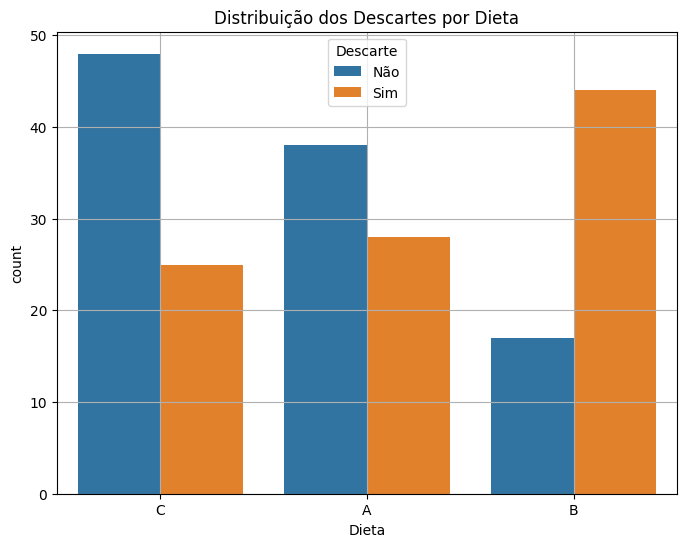

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Dieta', hue='Descarte')
plt.title('Distribuição dos Descartes por Dieta')
plt.grid(True)
plt.show()

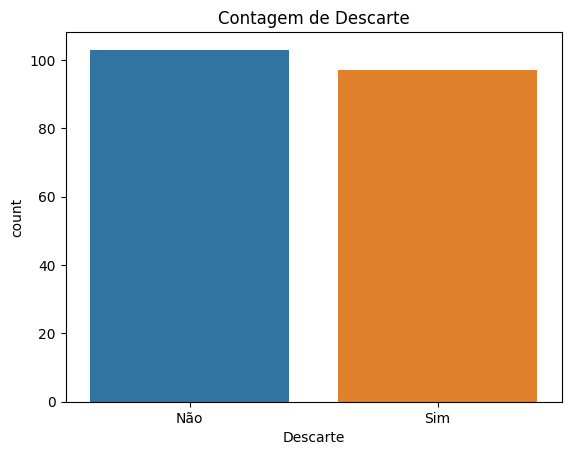

In [ ]:
for column in categorical_columns:
    sns.countplot(data=df, x=column, hue="Descarte")
    plt.title(f"Contagem de {column}")
    plt.show()

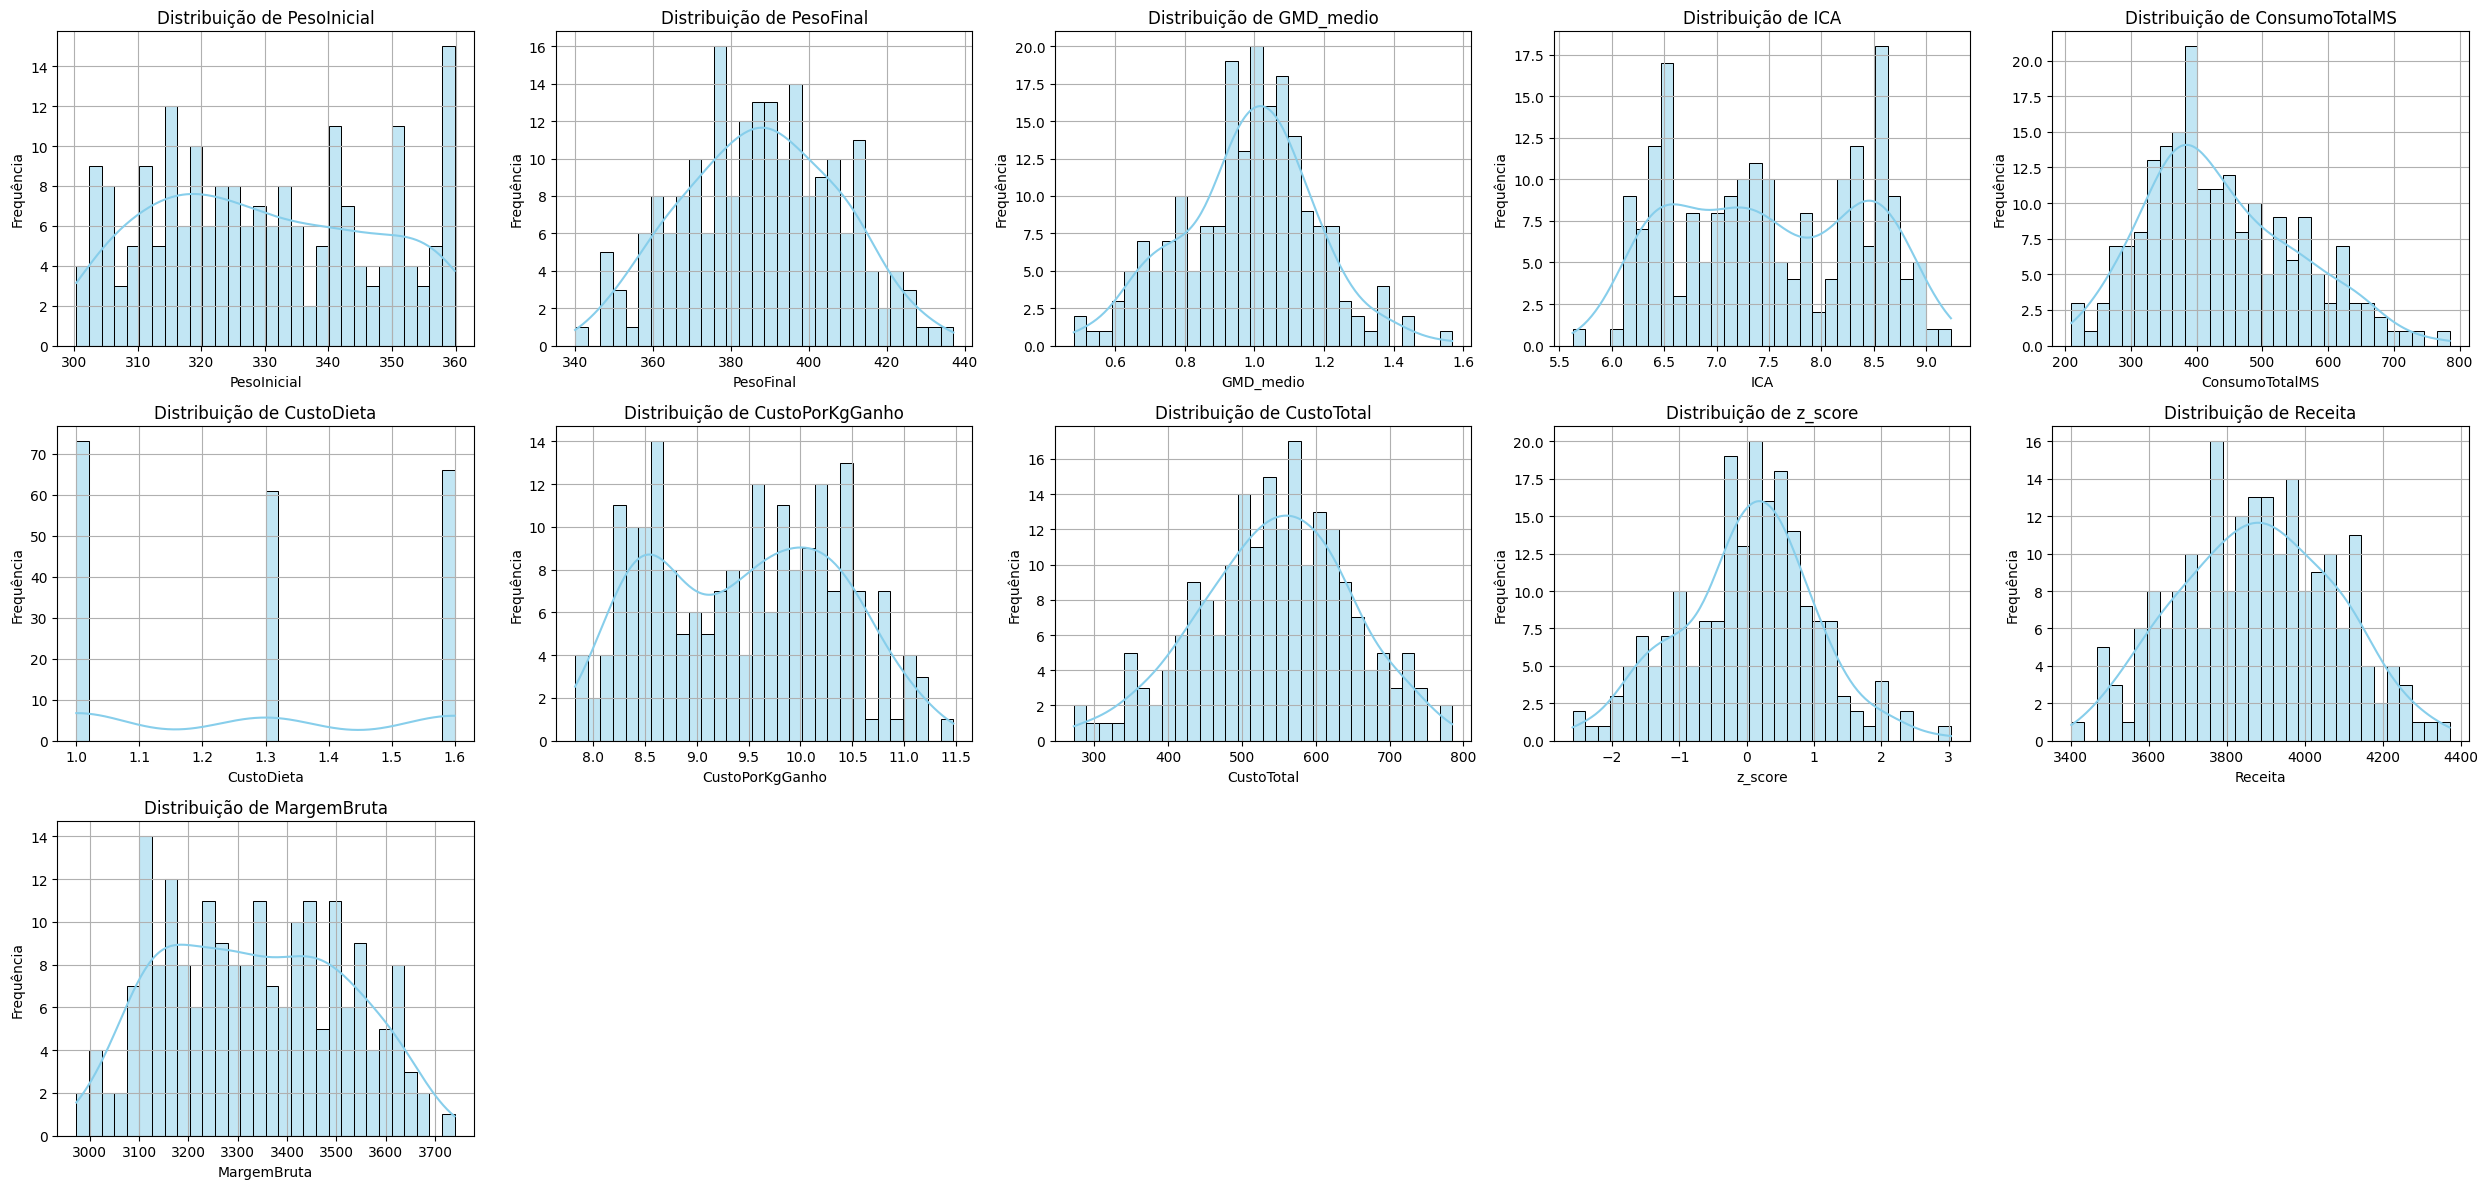

In [ ]:
#===================================================================================
#   Distribuição conjunta de todas as variáveis. É importantes notar que todas elas
#     apresentam uma distrinuição normal. Se a intenção for usar testes não
#     paramétricos podemos utilizar alternativas não paramétricos: Mann-Whitney U,
#     Kruskal-Wallis e outros, ou tentar fazer transformações do tipo o Z-score
#===================================================================================

# Número de colunas por linha
colunas_por_linha = 5

# Número total de variáveis
total = len(variaveis_de_interesse)

# Número de linhas necessárias (arredondado para cima
linhas = math.ceil(total / colunas_por_linha)

# Tamanho da figura ajustado à quantidade de linhas/colunas
fig, axes = plt.subplots(linhas, colunas_por_linha, figsize=(5 * colunas_por_linha, 4 * linhas))
axes = axes.flatten()  # transforma para vetor 1D para facilitar iteração

# Gera um histograma com KDE para cada variável
for i, coluna in enumerate(variaveis_de_interesse):
    ax = axes[i]
    sns.histplot(data=df, x=coluna, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribuição de {coluna}', fontsize=12)
    ax.set_xlabel(coluna)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Remove eixos vazios se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
#=================================================================================
#   BoxPlot das variaveis, para resumir a distribuição estatísticas dos dados, para
#   mostrar intervalo interquartil (IQR) e detectar outliers, avaliar assimetria,
#   observar medianas, ideal para as variáveis como o GMD, ICA e CustoTotal
#
#     Box: de Q1 (25%) a Q3 (75%)
#     Linha interna:  mediana (50%)
#     Bigodes: extensão do menor e o maior valor sem outliers
#     Pontos fora: outlies
#     mi: média da amostra/distribuição
#=================================================================================

import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Número de colunas por linha
colunas_por_linha = 4

# Inicializa os títulos customizados
subplot_titles = []

# Calcula os títulos com média, n e outliers
for col in variaveis_de_interesse:
    valores = df[col].dropna()
    media = valores.mean()
    n = len(valores)
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = ((valores < lim_inf) | (valores > lim_sup)).sum()

    titulo = f"{col}<br>µ={media:.2f} | n={n} | outliers={outliers}"
    subplot_titles.append(titulo)

# Total de variáveis e número de linhas
total_variaveis = len(variaveis_de_interesse)
linhas = math.ceil(total_variaveis / colunas_por_linha)

# Cria o layout de subplots
fig = make_subplots(
    rows=linhas,
    cols=colunas_por_linha,
    subplot_titles=subplot_titles
)

# Adiciona os boxplots
for i, col in enumerate(variaveis_de_interesse):
    linha = (i // colunas_por_linha) + 1
    coluna = (i % colunas_por_linha) + 1
    fig.add_trace(
        go.Box(y=df[col], name=col, boxpoints='outliers'),
        row=linha, col=coluna
    )

# Ajusta o layout
fig.update_layout(
    title_text="Boxplots com Estatísticas Resumidas",
    title_x=0.5,
    showlegend=False,
    height=400 * linhas,
    width=1200,
    template='plotly_white'
)

fig.show()




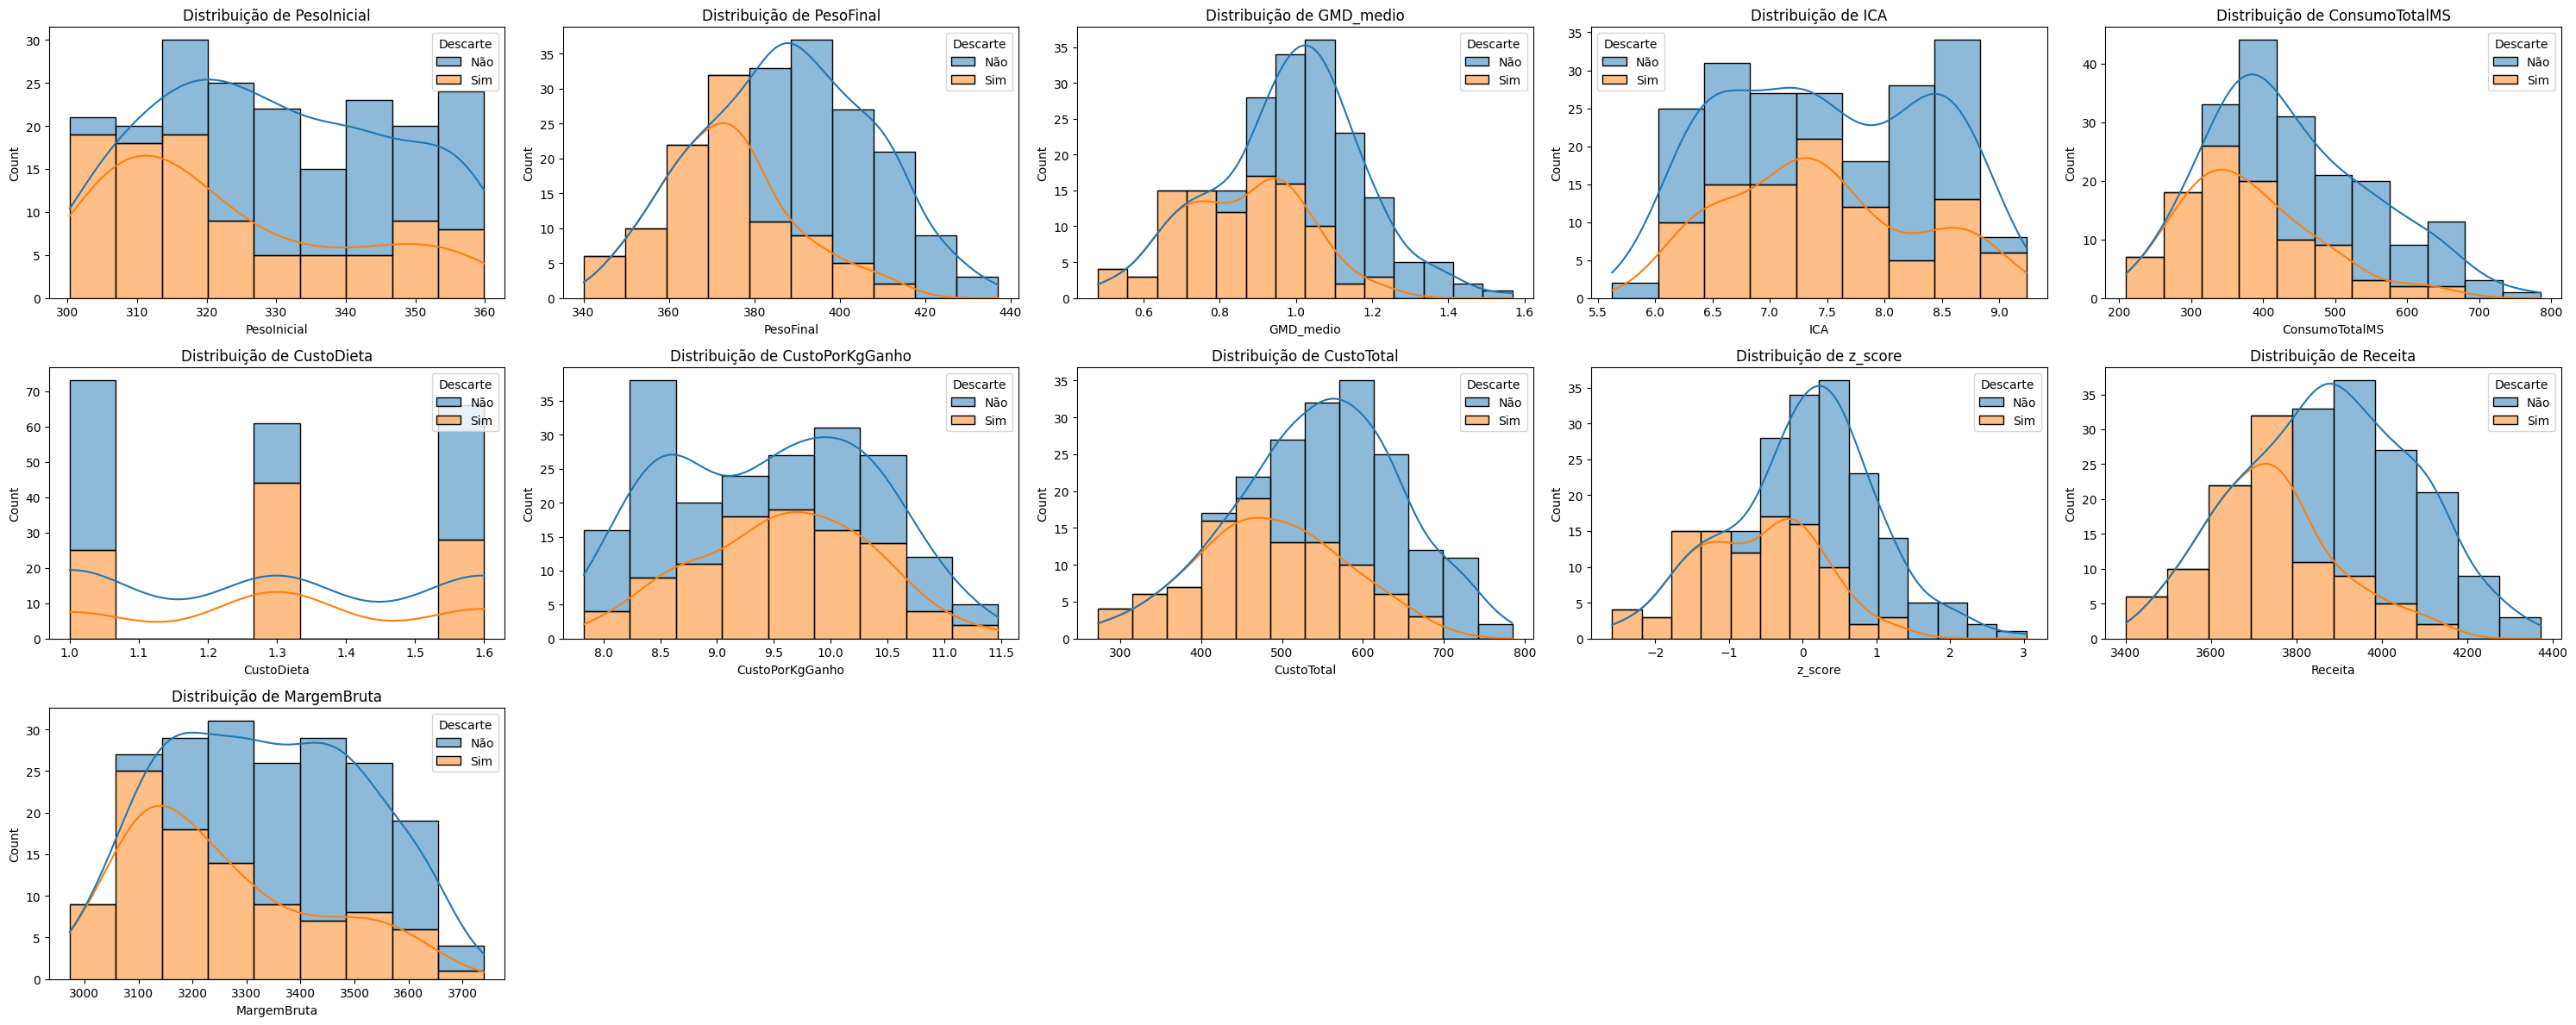

In [ ]:
#===============================================================================
#   Distribuição das variáveis em relação a variável-alvo (Descarte)
#===============================================================================

# Número de colunas que você deseja (ajuste conforme necessário)
n_cols = 5

# Número total de gráficos
n = len(variaveis_de_interesse)

# Calcula número de linhas necessárias (arredonda para cima)
n_rows = math.ceil(n / n_cols)

# Tamanho da figura total (ajuste o tamanho de cada subplot)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Transforma os eixos em uma lista para facilitar a iteração

# Loop pelas variáveis e gera os histogramas
for i, column in enumerate(variaveis_de_interesse):
    sns.histplot(data=df, x=column, hue="Descarte", multiple="stack", kde=True, ax=axes[i])
    axes[i].set_title(f"Distribuição de {column}")

# Remove subplots vazios (caso o número de variáveis seja menor que n_rows * n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


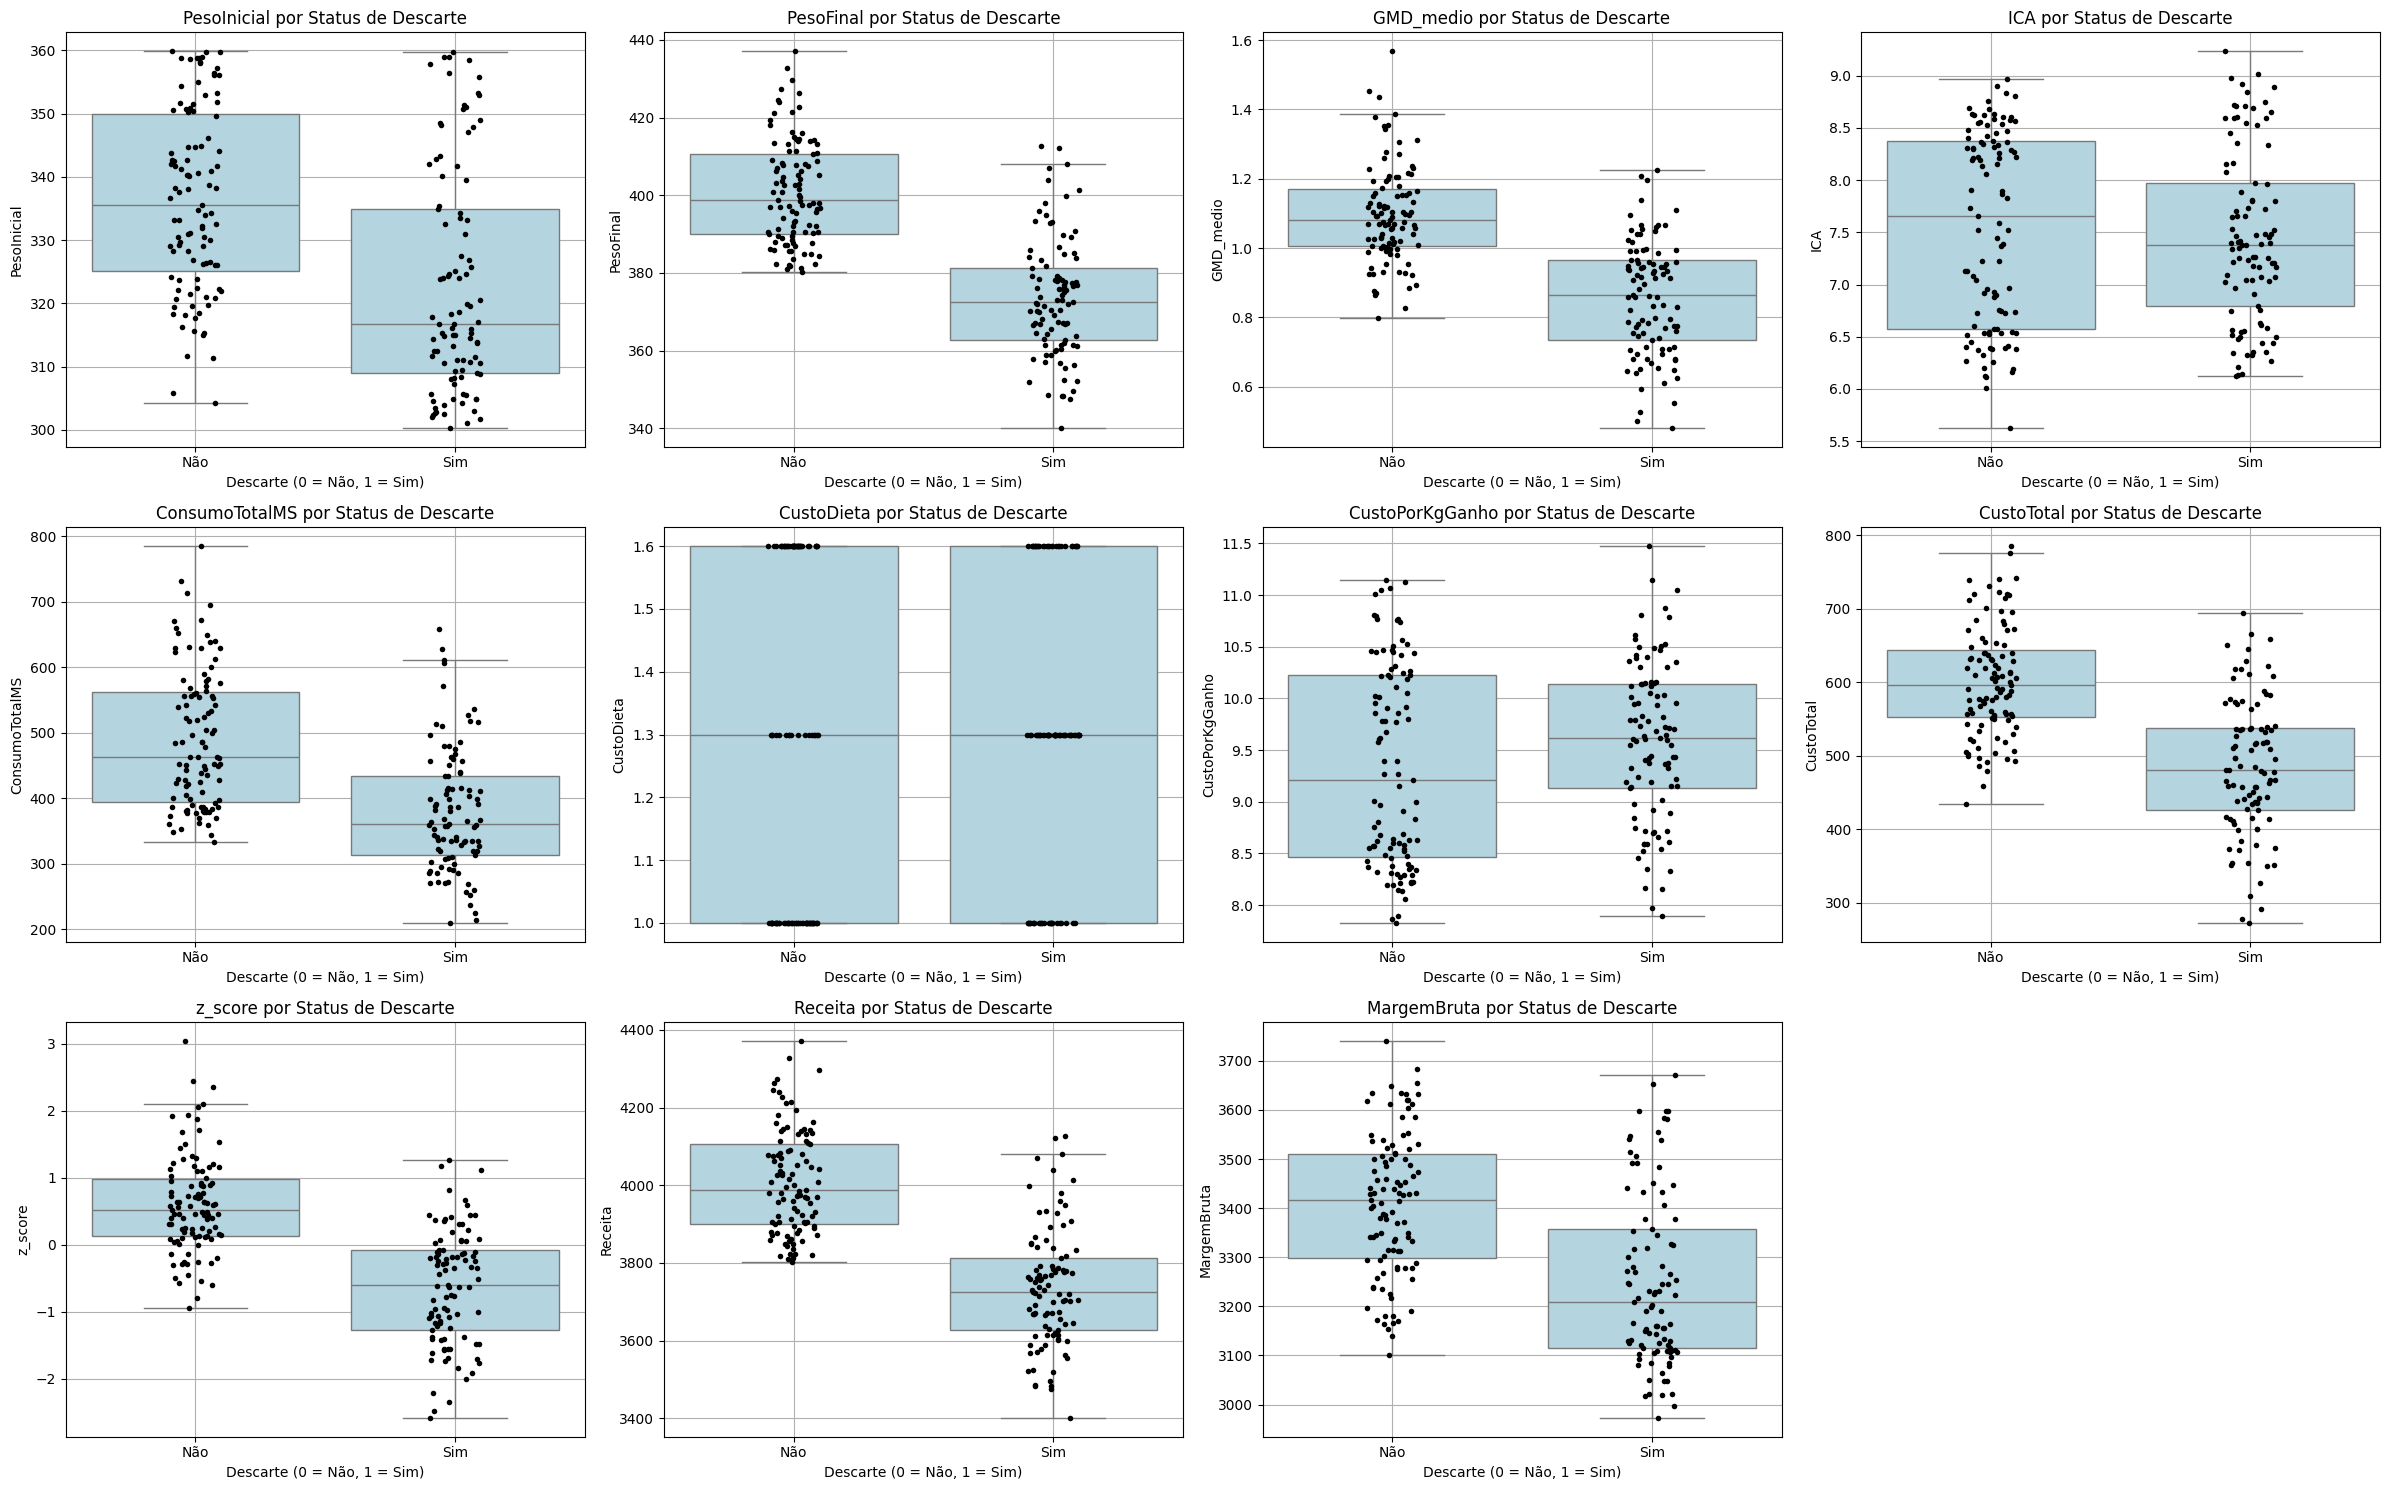

In [ ]:
#===============================================================================
#   Boxplot da variáveis em relação a variável-alvo. Aqui pode-se
#   claramente os ouliers. Optamos por nã elimina-los do dataset
#   Vantagens: Reduz a distorção das médias e variâncias, que podem inflar médias
#               e desvios-padrão e ajuda no desempenho de algoritmos de ML
#   Desvantagens: perda de informações importantes, viés na análise e pode
#               afetar a representatividade
#===============================================================================

# Definir grid
n_col = 4
n_row = math.ceil(len(variaveis_de_interesse) / n_col)

plt.figure(figsize=(n_col * 6, n_row * 5))

for i, column in enumerate(variaveis_de_interesse, 1):
    plt.subplot(n_row, n_col, i)

    sns.boxplot(
        data=df,
        x='Descarte',
        y=column,
        color='lightblue',
        showfliers=False
    )

    sns.stripplot(
        data=df,
        x='Descarte',
        y=column,
        color='black',
        size=4,
        jitter=True
    )

    plt.title(f'{column} por Status de Descarte')
    plt.xlabel('Descarte (0 = Não, 1 = Sim)')
    plt.ylabel(column)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Exportar o dataset .CSV no arquivo local
df.to_csv("Dataset_Bovinos_de_Corte.csv", index=False)
print("Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!")

Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!


# 7.1 Aplicação de Testes Estatísticos

<table border="1" cellspacing="0" cellpadding="6">
  <thead style="background-color:#4472C4; color:white; text-align:center;">
    <tr>
      <th>Teste</th>
      <th>Objetivo</th>
      <th>H₀ (Hipótese Nula)</th>
      <th>Rejeita H₀ se p &lt; α?</th>
      <th>Se rejeitar H₀</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:#D9E1F2;">
      <td>Shapiro-Wilk</td>
      <td>Verificar normalidade dos dados</td>
      <td>Os dados seguem uma distribuição normal</td>
      <td style="text-align:center;">Sim</td>
      <td>Os dados não são normais</td>
    </tr>
    <tr>
      <td>Levene</td>
      <td>Verificar igualdade de variâncias</td>
      <td>As variâncias dos grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>As variâncias são diferentes</td>
    </tr>
    <tr style="background-color:#D9E1F2;">
      <td>Teste t de Student</td>
      <td>Comparar médias entre dois grupos</td>
      <td>As médias dos dois grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>As médias são diferentes</td>
    </tr>
    <tr>
      <td>ANOVA (one-way)</td>
      <td>Comparar médias entre ≥3 grupos</td>
      <td>As médias de todos os grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>Pelo menos uma média é diferente</td>
    </tr>
    <tr style="background-color:#D9E1F2;">
      <td>Tukey HSD</td>
      <td>Comparar pares de médias (pós-ANOVA)</td>
      <td>As médias dos pares de grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>As médias dos grupos comparados são diferentes</td>
    </tr>
    <tr>
      <td>Wilks’ Lambda (MANOVA)</td>
      <td>Comparar médias multivariadas</td>
      <td>Os vetores médios dos grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>Há diferenças multivariadas entre os grupos</td>
    </tr>
    <tr style="background-color:#D9E1F2;">
      <td>Mann-Whitney</td>
      <td>Comparar distribuições (dados não normais)</td>
      <td>As distribuições dos grupos são iguais</td>
      <td style="text-align:center;">Sim</td>
      <td>As distribuições dos grupos são diferentes</td>
    </tr>
  </tbody>
</table>



In [ ]:
# Converte os valores da coluna Descarte: 'Sim' → 1, 'Não' → 0 para fazer comparações numéricas
df['Descarte'] = df['Descarte'].map({'Sim': 1, 'Não': 0})

In [ ]:
#===============================================================================
#           Variáveis foco para os testes estatisticos
#           Restringir a quantidade de variáveis para análise
#===============================================================================
variaveis = ['GMD_medio','ICA','CustoPorKgGanho','CustoTotal']

In [ ]:
df

,AnimalID,Dieta,PesoInicial,PesoFinal,GMD_medio,z_score,ICA,Media_GMD_Dieta,DP_GMD_Dieta,Limiar_GMD,CustoDieta,ConsumoTotalMS,CustoTotal,CustoPorKgGanho,Receita,MargemBruta,Descarte
0,1,C,324.230170,396.798933,1.229979,1.287324,8.679969,1.115901,0.151809,0.964092,1.0,629.894609,629.894609,8.679969,3967.989329,3338.094720,0
1,2,A,303.893535,360.429463,0.958236,-0.118343,6.439939,0.997037,0.133787,0.863250,1.6,364.087901,582.540642,10.303902,3604.294628,3021.753986,1
2,3,C,315.234925,372.183990,0.965238,-0.082121,8.352651,1.115901,0.151809,0.964092,1.0,475.675663,475.675663,8.352651,3721.839900,3246.164237,1
3,4,C,314.812564,377.680411,1.065557,0.436803,7.891231,1.115901,0.151809,0.964092,1.0,496.104692,496.104692,7.891231,3776.804114,3280.699422,1
4,5,A,341.778256,405.123544,1.073649,0.478663,6.112689,0.997037,0.133787,0.863250,1.6,387.210054,619.536086,9.780303,4051.235440,3431.699353,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,B,320.512780,367.481348,0.796077,-0.957154,7.260020,0.802584,0.148726,0.653858,1.3,340.992762,443.290591,9.438027,3674.813478,3231.522887,1
196,197,C,305.507944,377.770809,1.224794,1.260504,8.694509,1.115901,0.151809,0.964092,1.0,628.290102,628.290102,8.694509,3777.708095,3149.417993,1
197,198,C,305.649419,361.433683,0.945496,-0.184244,8.607808,1.115901,0.151809,0.964092,1.0,480.180237,480.180237,8.607808,3614.336834,3134.156596,1
198,199,B,318.684799,374.214599,0.941183,-0.206554,7.479970,0.802584,0.148726,0.653858,1.3,415.361253,539.969629,9.723961,3742.145989,3202.176360,1


In [ ]:
#===============================================================================
#  1️⃣ Comparar as principais variáveis com a variavel Descarte (ALVO)
#         Obs:  Uma boa prática em Python
#===============================================================================

def comparar_variaveis(df, variaveis, grupo_col='Descarte'):
    resultados = []
    grupo_sim = df[df[grupo_col] == 1]
    grupo_nao = df[df[grupo_col] == 0]

    for var in variaveis:
        dados_sim = grupo_sim[var].dropna()
        dados_nao = grupo_nao[var].dropna()

        n1 = len(dados_sim)
        n2 = len(dados_nao)

        if n1 < 2 or n2 < 2:
            resultados.append({
                'Variável': var,
                'Teste': 'N/A',
                'Estatística': 'N/A',
                'p-valor': 'N/A',
                'Resultado': 'Dados insuficientes'
            })
            continue

        # Testar normalidade nos dois grupos

        p_norm1 = shapiro(dados_sim).pvalue
        p_norm2 = shapiro(dados_nao).pvalue
        normal = p_norm1 > 0.05 and p_norm2 > 0.05

        if normal:
            t_stat, p_valor = ttest_ind(dados_sim, dados_nao, equal_var=False)
            teste = "Teste t de Welch"
        else:
            t_stat, p_valor = mannwhitneyu(dados_sim, dados_nao, alternative='two-sided')
            teste = "Mann-Whitney U"

        resultados.append({
            'Variável': var,
            'Teste': teste,
            'Estatística': round(t_stat, 4),
            'p-valor': round(p_valor, 5),
            'Resultado': 'Diferença significativa' if p_valor <= 0.05 else 'Diferença não significativa'
        })
    return pd.DataFrame(resultados)

resultado_testes = comparar_variaveis(df, variaveis)
display(resultado_testes)

,Variável,Teste,Estatística,p-valor,Resultado
0,GMD_medio,Mann-Whitney U,1304.000,0.00000,Diferença significativa
1,ICA,Mann-Whitney U,4802.000,0.63708,Diferença não significativa
2,CustoPorKgGanho,Mann-Whitney U,5806.000,0.04770,Diferença significativa
3,CustoTotal,Teste t de Welch,-9.848,0.00000,Diferença significativa


<table>
  <tr>
    <th>Variável</th>
    <th>Resultado</th>
    <th>Implicação</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td> GMD_medio</td>
    <td>Descartados têm GMD médio significativamente menor</td>
    <td>Um dos melhores critérios objetivos de desempenho produtivo para descarte</td>
    <td>Recomendado usar em modelo de decisão</td>
  <tr>
    <td>ICA</td>
    <td>Sem diferença estatística</td>
    <td>ICA isoladamente não explica o descarte no seu rebanho</td>
    <td>Pode complementar outras métricas, mas não serve como critério principal</td>
  </tr>
     <td>CustoPorKgGanho</td>
    <td>Diferença estatisticamente significativa (p < 0.05)</td>
    <td>Animais descartados estão menos eficientes economicamente</td>
    <td> Indicador importante para avaliar viabilidade de permanência no sistema</td>
  </tr>
    <td>CustoTotal</td>
    <td>Altamente significativo (p ≈ 0.0000)</td>
    <td>Animais descartados geram maior custo absoluto</td>
    <td>Reforça o GMD como fator decisivo (baixo desempenho com alto custo)</td>
  </tr>

In [ ]:
#       Plotar as variáveis pela variável ALVO (Descarte) para verificar as distribuiçōes

plt.figure(figsize=(8, 4))

def plotar_distribuicoes_por_grupo(df, variaveis, grupo_col='Descarte'):
    for var in variaveis:
        # Garantir que a variável seja numérica
        df[var] = pd.to_numeric(df[var], errors='coerce')

        grupo_0 = df[(df[grupo_col] == 0) & (df[var].notna())][var]
        grupo_1 = df[(df[grupo_col] == 1) & (df[var].notna())][var]

        if len(grupo_0) > 0 and len(grupo_1) > 0:
            plt.figure(figsize=(8, 4))

            sns.histplot(grupo_0, color='skyblue', label='Não descartado',
                         kde=True, stat='density', bins=30, edgecolor='black', alpha=0.6)

            sns.histplot(grupo_1, color='darkorange', label='Descartado',
                         kde=True, stat='density', bins=30, edgecolor='black', alpha=0.6)

            plt.title(f'Distribuição da variável: {var}', fontsize=14)
            plt.xlabel(var, fontsize=12)
            plt.ylabel('Densidade', fontsize=12)
            plt.legend(title='Condição do Animal')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        else:
            print(f"⚠️ Variável '{var}' sem dados suficientes nos dois grupos para plotagem.")

<Figure size 800x400 with 0 Axes>

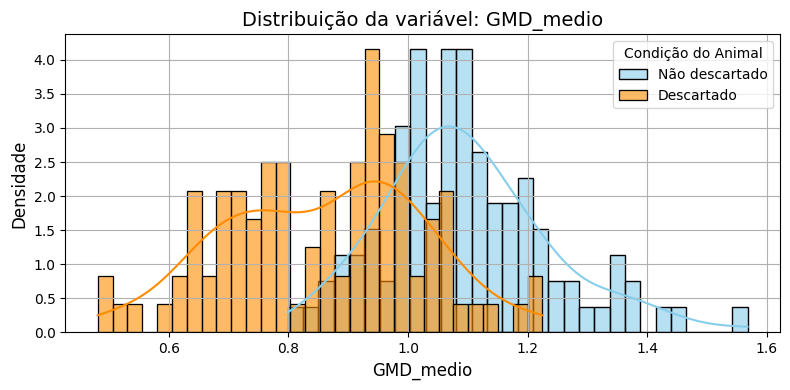

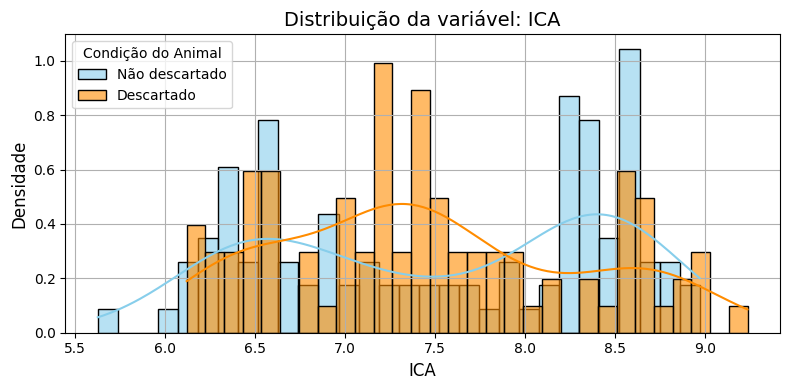

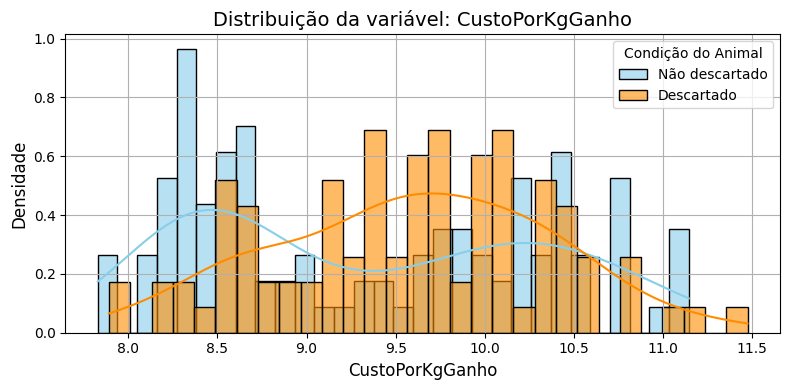

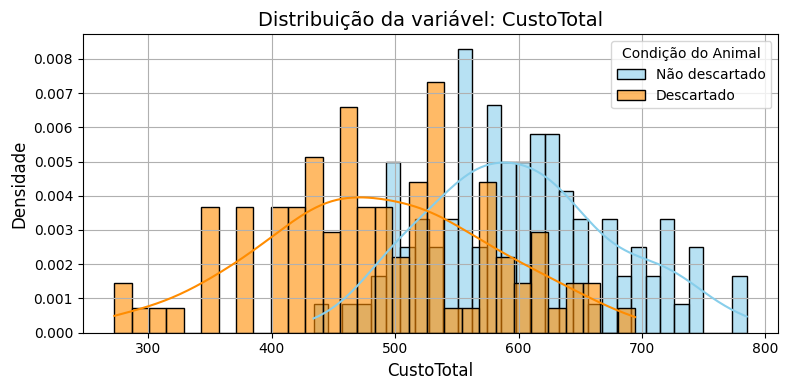

In [ ]:
plotar_distribuicoes_por_grupo(df, variaveis)

In [ ]:
# ==============================================================================
# 2️⃣ Verificação de normalidade (Shapiro-Wilk)
# ==============================================================================

for var in variaveis:
    stat, p = shapiro(df[var])
    print(f"🔍 Shapiro-Wilk para {var}: W={stat:.4f}, p={p:.4f} => {'Normal' if p > 0.05 else 'Não Normal'}")

🔍 Shapiro-Wilk para GMD_medio: W=0.9912, p=0.2685 => Normal
🔍 Shapiro-Wilk para ICA: W=0.9468, p=0.0000 => Não Normal
🔍 Shapiro-Wilk para CustoPorKgGanho: W=0.9630, p=0.0000 => Não Normal
🔍 Shapiro-Wilk para CustoTotal: W=0.9938, p=0.5782 => Normal


**Comentários:** As distribuicoes das variáveis, GMB_medio, e CustoTotal, são **normais**, como pode ser comprovado pelos gráficos abaixo, comparando-se os valores de p < ou > 0.05. Nas distribuições normais podemos utilizar o teste **t de Student**, nas outras a indicação poderia ser o teste **Mann-Whitney**.



In [ ]:
# ==============================================================================
# 3️⃣ Teste de homogeneidade das variâncias (Levene entre Dietas)
# ==============================================================================

for var in variaveis:
    grupos = [g[var].dropna() for name, g in df.groupby("Dieta")]
    stat, p = levene(*grupos)
    print(f" Levene para {var} por Dieta: stat={stat:.4f}, p={p:.4f}")

 Levene para GMD_medio por Dieta: stat=0.8225, p=0.4408
 Levene para ICA por Dieta: stat=0.3132, p=0.7315
 Levene para CustoPorKgGanho por Dieta: stat=3.4132, p=0.0349
 Levene para CustoTotal por Dieta: stat=1.2997, p=0.2749


**Comentários:** A variância mede o quanto os dados se espalham em torno da média.
Se os grupos têm variâncias muito diferentes, isso pode afetar a confiabilidade de testes como o teste t ou ANOVA.

*   Quando p > 0.05: você pode assumir igualdade de variâncias → usar os testes ANOVA padrão ou t de Studant
*   Quando p < 0.05: há violação da homogeneidade de variâncias → usar:
  *   ANOVA de Welch (para mais de dois grupos)
  *   Teste t de Welch (para dois grupos)
  * Ou testes não paramétricos
*   Se as violações das suposições forem violadas os resultados podem ser enganosos (erros tipo I ou II)


# ==========================================================
# Comparação das variâncias por Dieta (ANOVA ou teste de Tukey)
# ==========================================================

for var in variaveis:
    grupos = [g[var].dropna() for name, g in df.groupby("Dieta")]
    print(f"\nComparação entre dietas para {var}:")
    if all(shapiro(g)[1] > 0.05 for g in grupos):
        stat, p = f_oneway(*grupos)
        print(f"  ANOVA: F={stat:.4f}, p={p:.4f}")
        if p < 0.05:
            tukey = pairwise_tukeyhsd(endog=df[var], groups=df['Dieta'], alpha=0.05)
            print(tukey)
    else:
        stat, p = kruskal(*grupos)
        print(f"  Kruskal-Wallis: H={stat:.4f}, p={p:.4f}")

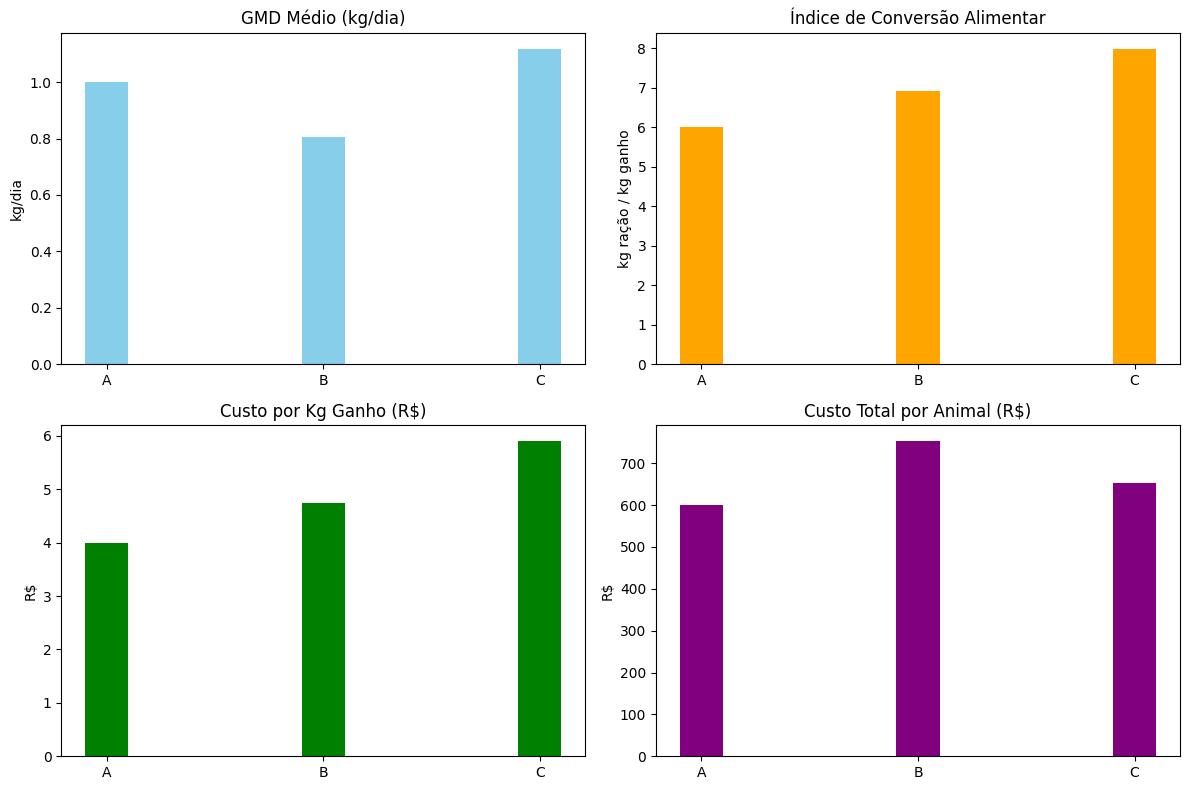

In [ ]:
# ==============================================================================
# 4️⃣ Comparação das variâncias por Dieta (ANOVA ou teste de Tukey)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Dados simulados com base nos resultados da ANOVA e Tukey HSD
dietas = ['A', 'B', 'C']
GMD_medio = [1.0, 0.8055, 1.1189]           # A = base; B = A - 0.1945; C = A + 0.1189
ICA = [6.0, 6.9212, 7.9899]                 # A = base; B = A + 0.9212; C = A + 1.9899
CustoPorKg = [4.0, 4.7502, 5.9056]          # A = base; B = A + 0.7502; C = A + 1.9056
CustoTotal = [600, 753.22, 651.74]          # A = base; B = A + 153.22; C = A + 51.74

# Posição dos grupos no eixo X
x = np.arange(len(dietas))
width = 0.2

# Criar subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

# Gráfico 1: GMD Médio
axs[0].bar(x, GMD_medio, width=width, color='skyblue')
axs[0].set_title("GMD Médio (kg/dia)")
axs[0].set_xticks(x)
axs[0].set_xticklabels(dietas)
axs[0].set_ylabel("kg/dia")

# Gráfico 2: ICA
axs[1].bar(x, ICA, width=width, color='orange')
axs[1].set_title("Índice de Conversão Alimentar")
axs[1].set_xticks(x)
axs[1].set_xticklabels(dietas)
axs[1].set_ylabel("kg ração / kg ganho")

# Gráfico 3: Custo por Kg Ganho
axs[2].bar(x, CustoPorKg, width=width, color='green')
axs[2].set_title("Custo por Kg Ganho (R$)")
axs[2].set_xticks(x)
axs[2].set_xticklabels(dietas)
axs[2].set_ylabel("R$")

# Gráfico 4: Custo Total por Animal
axs[3].bar(x, CustoTotal, width=width, color='purple')
axs[3].set_title("Custo Total por Animal (R$)")
axs[3].set_xticks(x)
axs[3].set_xticklabels(dietas)
axs[3].set_ylabel("R$")

plt.tight_layout()
plt.show()


In [ ]:
# ===============================================================================
#  5️⃣ Outliers (z-score e IQR)
# ==============================================================================
print("\n Outliers:")
for var in variaveis:
    z_scores = np.abs(zscore(df[var]))
    outliers = df[z_scores > 3]
    print(f"{var}: {len(outliers)} outliers com z > 3")


 Outliers:
GMD_medio: 1 outliers com z > 3
ICA: 0 outliers com z > 3
CustoPorKgGanho: 0 outliers com z > 3
CustoTotal: 0 outliers com z > 3


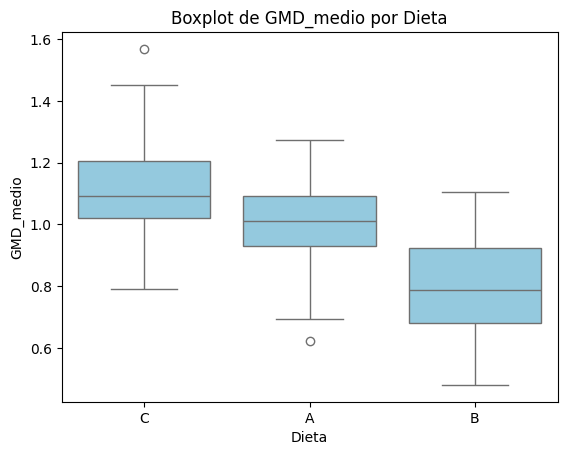

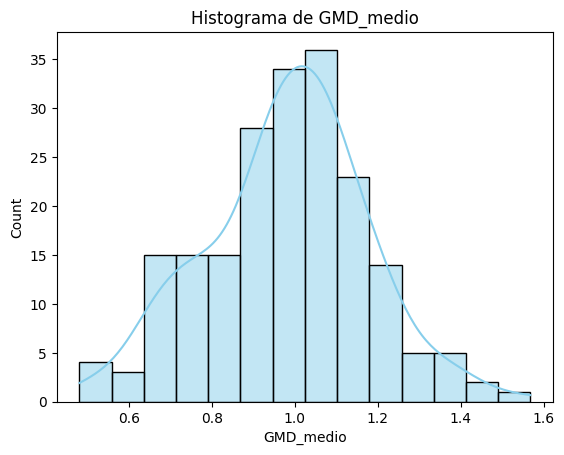

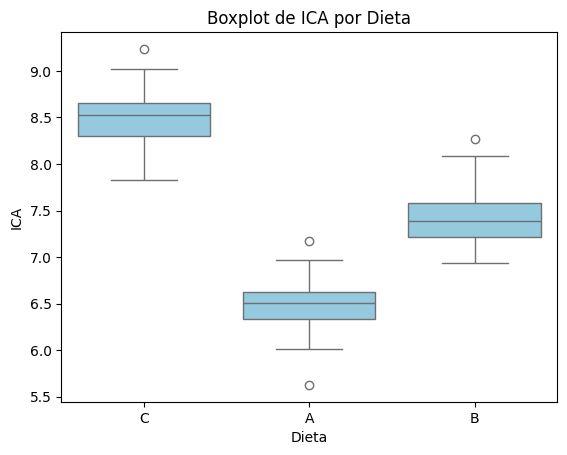

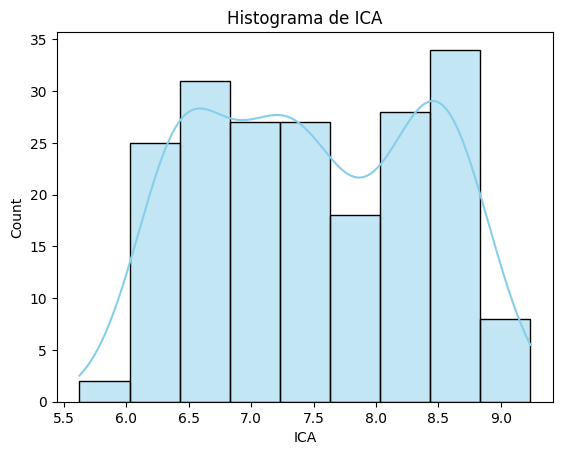

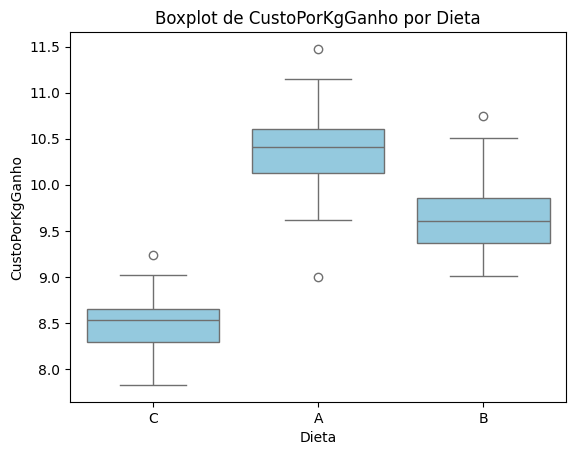

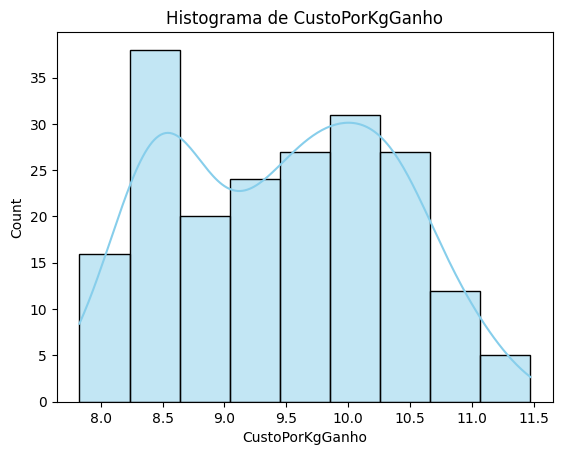

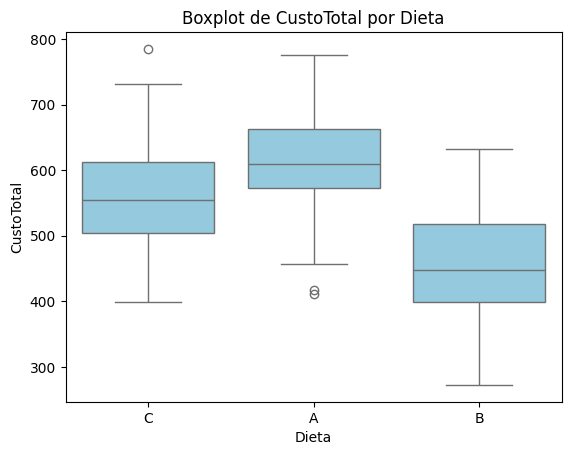

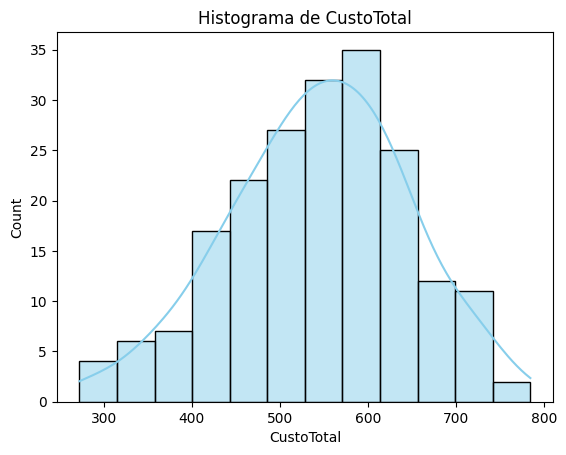

In [ ]:
# ==============================================================================
# 6️⃣ Boxplots e Histogramas
# ==============================================================================

for var in variaveis:
    sns.boxplot(data=df, x='Dieta', y=var, color='skyblue')
    plt.title(f'Boxplot de {var} por Dieta')
    plt.show()

    sns.histplot(df[var], kde=True, color='skyblue')
    plt.title(f'Histograma de {var}')
    plt.show()

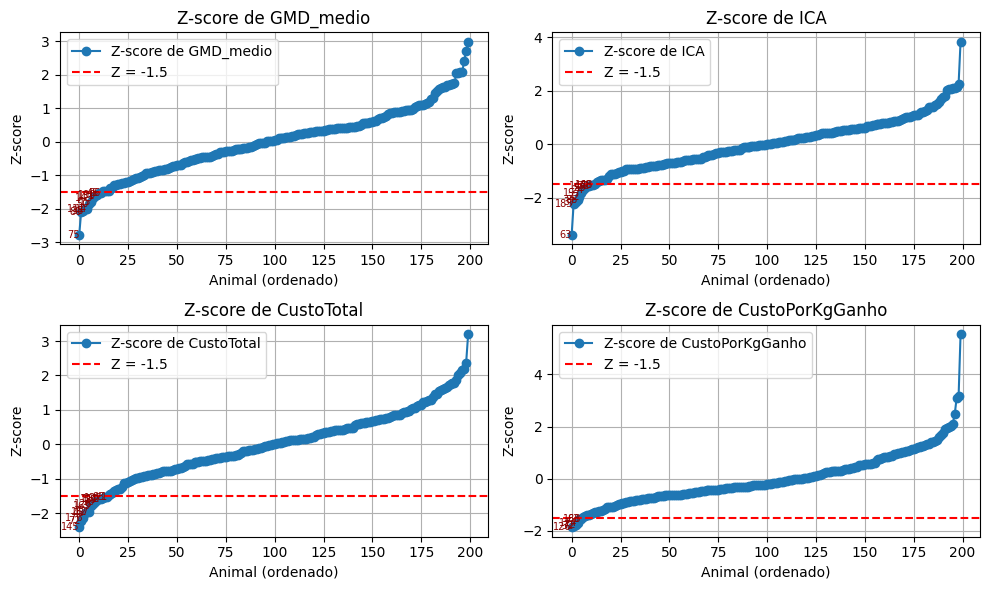

In [ ]:
#===============================================================================
# 7️⃣      Comparativo do desempenho medio (Z-score de cada animal)
#===============================================================================

# Simular dados
np.random.seed(42)
num_animais = 200
df = pd.DataFrame({
    'AnimalID': range(1, num_animais + 1),
    'GMD_medio': np.random.normal(1.0, 0.2, size=num_animais),
    'ICA': np.random.normal(7.0, 0.5, size=num_animais),
    'CustoTotal': np.random.normal(500, 50, size=num_animais)
})
df['CustoPorKgGanho'] = df['CustoTotal'] / (df['GMD_medio'] * 30)

# Lista de variáveis para análise
variaveis = ['GMD_medio', 'ICA', 'CustoTotal', 'CustoPorKgGanho']

# Criar subplots em colunas (2 linhas x 2 colunas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.flatten()

# Gerar gráficos
for i, var in enumerate(variaveis):
    estat = df[['AnimalID', var]].copy()
    media = estat[var].mean()
    desvio = estat[var].std(ddof=0)
    estat['z_score'] = (estat[var] - media) / desvio
    estat_sorted = estat.sort_values('z_score').reset_index(drop=True)

    axes[i].plot(estat_sorted['z_score'].values, marker='o', linestyle='-', label=f'Z-score de {var}')
    axes[i].axhline(-1.5, color='red', linestyle='--', label='Z = -1.5')

    # Anotar animais com z-score < -1.5
    for idx, row in estat_sorted.iterrows():
        if row['z_score'] < -1.5:
            axes[i].text(idx, row['z_score'], str(int(row['AnimalID'])), fontsize=7, ha='right', va='center', color='darkred')

    axes[i].set_title(f'Z-score de {var}')
    axes[i].set_xlabel('Animal (ordenado)')
    axes[i].set_ylabel('Z-score')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()



# 7.1.1 Análise dos resultados
1.   O z-score de um animal mede quanto o valor de uma variável (ex: GMD_medio, ICA, CustoTotal) se afasta da média da população, em termos de desvios-padrão
2.    Na pecuária, serve para identificar animais fora do padrão (para descarte ou atenção especial)
3.   Classificar desempenho individual com base em critérios estatísticos
4.   Comparar variáveis diferentes (ex: GMD, ICA, Custo) em uma mesma escala
5.   O Z < -1.5 identifica animais com desempenho visivelmente abaixo da média, mas ainda estatisticamente confiável, e pode ser útil para decisões zootécnicas ou econômicas
6.   Como exemplo, animal com GMD = 0.75 → Z = -1.67 ⇒ abaixo de -1.5 → pode ser considerado improdutivo: Z = (media-mi)/desvio padrao
7.  Animal com GMD = 1.25 → Z = +1.67 ⇒ acima de +1.5 → potencial elite

<table>
  <tr>
    <th>Faixa de z-score</th>
    <th>% dos dados incluídos</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>Entre -1 e +1</td>
    <td>~68%</td>
    <td>Normal</td>
  <tr>
    <td>Entre -1.5 e +1.5-0.68</td>
    <td>~86.6%</td>
    <td>A maioria, ainda dentro de padrões comuns</td>
  </tr>
     <td>entre -2 e +2</td>
    <td>~95.4%</td>
    <td>Valores extremos começam a aparecer fora</td>
  </tr>
    <td>além de ±2</td>
    <td>~4.6%</td>
    <td>Suspeita de outlier</td>
  </tr>
    <td>além de ±3</td>
    <td>~0.3%</td>
    <td>Outlier extremo</td>
  </tr>

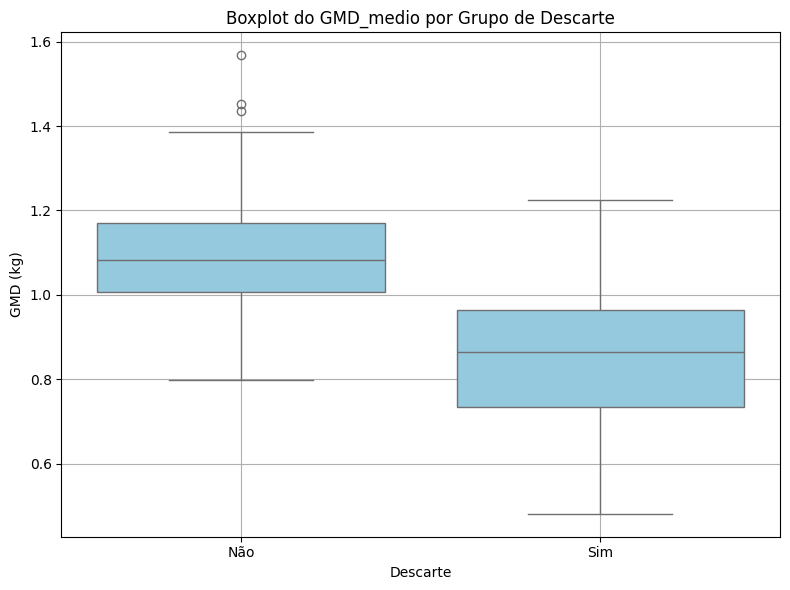

In [ ]:
#===============================================================================
# 8️⃣          Boxplot comparativo
#===============================================================================

# Reload the original dataframe from the saved CSV
df = pd.read_csv("Dataset_Bovinos_de_Corte.csv")

plt.figure(figsize=(8, 6))
sns.boxplot(data=df[df['GMD_medio'].notna()], x='Descarte', y='GMD_medio', color='skyblue')
plt.title('Boxplot do GMD_medio por Grupo de Descarte')
plt.ylabel('GMD (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 7.1.2 Importância das Variáveis

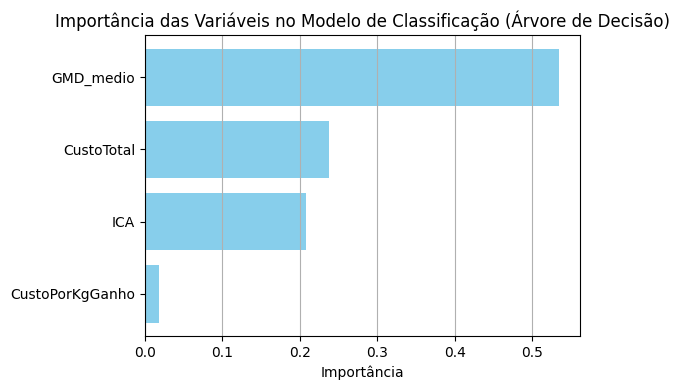

In [ ]:
#===============================================================================
# 9️⃣          Importância das variáveis
#===============================================================================

# Selecione features (X) and target (y)
# Exclui 'AnimalID' e 'Descarte' de features, and inclui colunas numéricas relevantes

X = df[variaveis]
y = df['Descarte']


# Initialize e treine uma Arvore de Decisão
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X, y)

# Pega as features importantes
importances = modelo_dt.feature_importances_
features = X.columns

# Ordenar por importância
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(features[sorted_idx], importances[sorted_idx], color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis no Modelo de Classificação (Árvore de Decisão)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

**Interpretação**: Cada barra horizontal representa uma variável (por exemplo, GMD_medio, ICA, CustoTotal, etc.), e o tamanho da barra mostra quanto essa variável contribui para a tomada de decisão da árvore, mostrando a alta utilizaçāo da variável GMD_medio e a menor utilizacao da variavel CustoPorKgGanho.

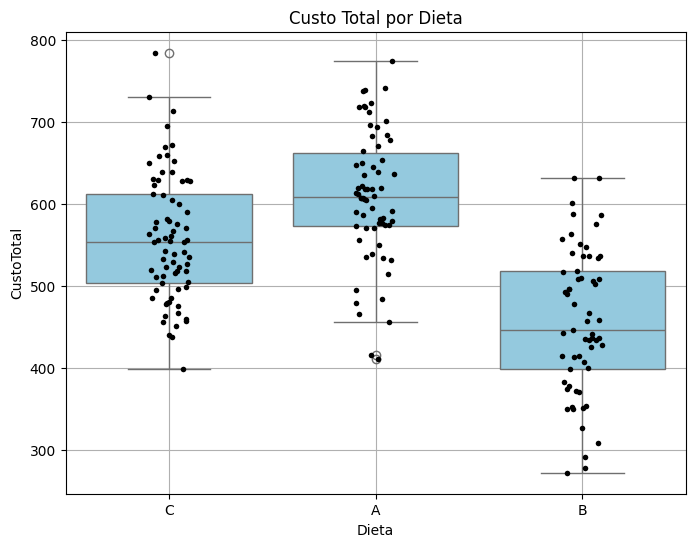

In [ ]:
#===============================================================================
#            Boxplot comparativo de CustoTotal por Dieta
#===============================================================================

plt.figure(figsize=(8, 6))
# Use the original df dataframe which contains 'CustoTotal'
sns.boxplot(data=df, x='Dieta', y='CustoTotal', color='skyblue')
sns.stripplot(data=df, x='Dieta', y='CustoTotal', color='black', size=4, jitter=True)

plt.title('Custo Total por Dieta')
plt.grid(True)
plt.show()

Esse gráfico mostra o custo com cada animal distribuido por dieta, alguns ouliers e a mediana da dieta "C" entre a dieta mais cara "A" e a mais barata "B".

# 7.1.3 Gráficos de Dispersão

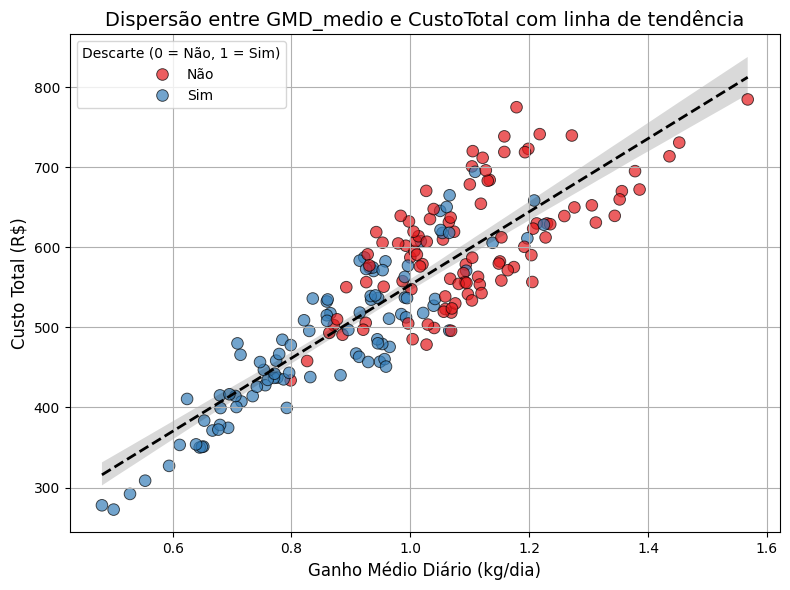

In [ ]:
#===============================================================================
# 🔟        Gráficos de Dispersão
#===============================================================================

# Garantir que os dados são numéricos
df['GMD_medio'] = pd.to_numeric(df['GMD_medio'], errors='coerce')
df['CustoTotal'] = pd.to_numeric(df['CustoTotal'], errors='coerce')

# Remover NaNs para evitar erros na regressão
df_plot = df[['GMD_medio', 'CustoTotal', 'Descarte']].dropna()

# Plotar a dispersão colorida
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='GMD_medio',
    y='CustoTotal',
    hue='Descarte',
    palette='Set1',
    s=70,
    alpha=0.7,
    edgecolor='black'
)

# Adicionar linha de tendência geral
sns.regplot(
    data=df_plot,
    x='GMD_medio',
    y='CustoTotal',
    scatter=False,          # não desenha pontos novamente
    color='black',          # cor neutra para a tendência
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('Dispersão entre GMD_medio e CustoTotal com linha de tendência', fontsize=14)
plt.xlabel('Ganho Médio Diário (kg/dia)', fontsize=12)
plt.ylabel('Custo Total (R$)', fontsize=12)
plt.legend(title='Descarte (0 = Não, 1 = Sim)')
plt.grid(True)
plt.tight_layout()
plt.show()


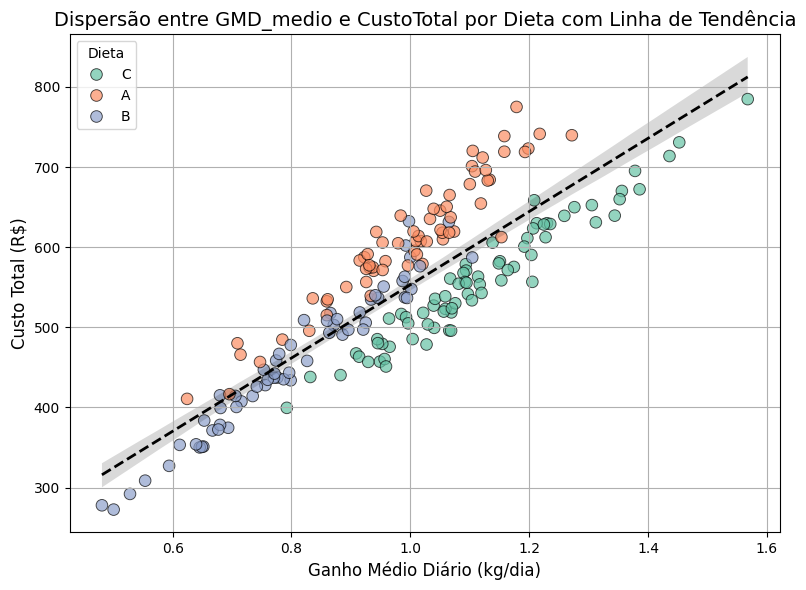

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Garantir que os dados são numéricos
df['GMD_medio'] = pd.to_numeric(df['GMD_medio'], errors='coerce')
df['CustoTotal'] = pd.to_numeric(df['CustoTotal'], errors='coerce')

# Remover NaNs
df_plot = df[['GMD_medio', 'CustoTotal', 'Dieta']].dropna()

# Gráfico de dispersão com cores por dieta
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='GMD_medio',
    y='CustoTotal',
    hue='Dieta',
    palette='Set2',
    s=70,
    alpha=0.7,
    edgecolor='black'
)

# Linha de tendência geral (única para todos os dados)
sns.regplot(
    data=df_plot,
    x='GMD_medio',
    y='CustoTotal',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

# Ajustes visuais
plt.title('Dispersão entre GMD_medio e CustoTotal por Dieta com Linha de Tendência', fontsize=14)
plt.xlabel('Ganho Médio Diário (kg/dia)', fontsize=12)
plt.ylabel('Custo Total (R$)', fontsize=12)
plt.legend(title='Dieta')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretação**: Gráfico de dispersão muito importante para visualizar a distribuicao da variáveis em torno de uma linha de tendência.

✅ No primeiro gráfico vemos a dispersao entre ganho medio diario x o custo total marcado com o label de descarte. Ve-se claramente que os animais descartados, em azul na parte inferior do graficos, sao aqueles com baixo ganho medio diario, como esperado, mas por alguma incongruencia nos dados gerados tambem seriam aqueles com **baixo custo total (sic)**, e o nao descartados seriam aqueles que apresentam um comportamento inverso **de alto custo (sic)**

✅ No segundo gráfico, comparando as dietas, com a dieta "B" os animais apresentaram os piores ganhos de peso, comparando com as dietas "A" e "B", como já tinha verificado com o teste de hipótese acima.



In [ ]:
# Reload the original dataframe from the saved CSV
df = pd.read_csv("Dataset_Bovinos_de_Corte.csv")

# 7.2 Verificação das Suposições (Análise dos Resídios)

A análise de resíduos é uma etapa fundamental em qualquer estudo estatístico que envolve modelos, especialmente regressão ou ANOVA. Aqui está por que ela é tão importante:

✅ 1. Verificar suposições dos testes estatísticos

*   seguem distribuição normal
*   têm variância constante (homocedasticidade)
*   são independentes

✅ 2. Melhorar a escolha do teste estatístico
*   Se normais e homogêneos → use testes paramétricos (como ANOVA, t de Student)
*   Se não normais ou heterocedásticos → prefira testes não paramétricos (como Mann-Whitney, Kruskal-Wallis)

✅ 3. Validar a confiabilidade das conclusões: Mesmo se um teste retornar um p-valor "bonito", a validade do resultado depende de os resíduos respeitarem as suposições. Ignorar a análise de resíduos pode levar a:
*   falsos positivos (erro tipo I)
*   falsos negativos (erro tipo II)

✅ 4. Diagnóstico de problemas no modelo
<table>
  <tr>
    <th>Comportamento do Resíduo</th>
    <th>Interpretação</th>
  </tr>
  <tr>
    <td>Padrões curvos ou sistemáticos</td>
    <td>O modelo pode estar mal especificado</td>
  <tr>
    <td>Variação crescente ou decrescente (funil)</td>
    <td>Heterocedasticidade (variância não constante)</td>
    <td>A maioria, ainda dentro de padrões comuns</td>
  </tr>
     <td>Muitos resíduos extremos (caudas pesadas)</td>
    <td>Observações influentes ou dados inconsistentes</td>
  </tr>

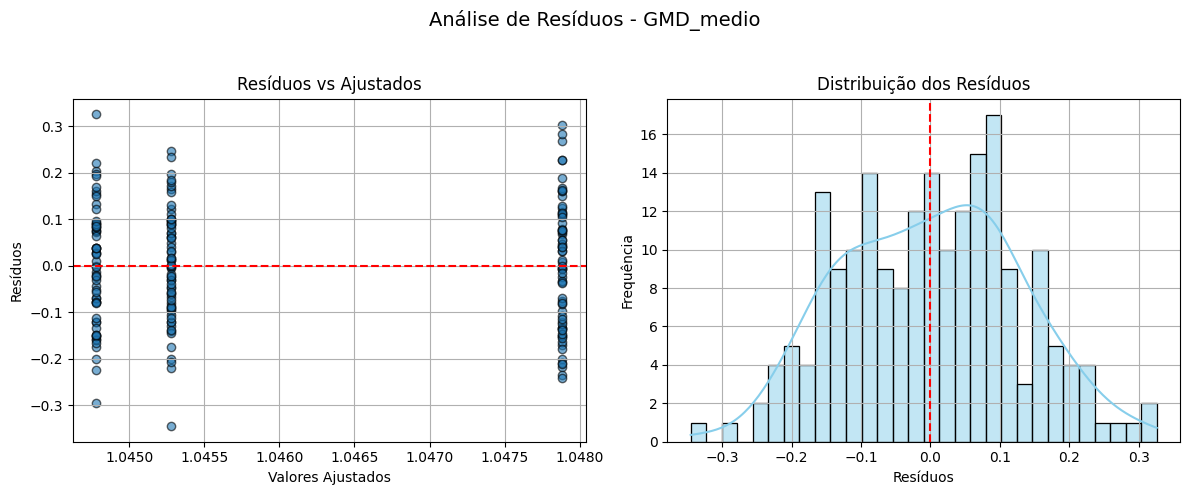

GMD_medio - Shapiro-Wilk: W=0.9930, p-valor=0.45724



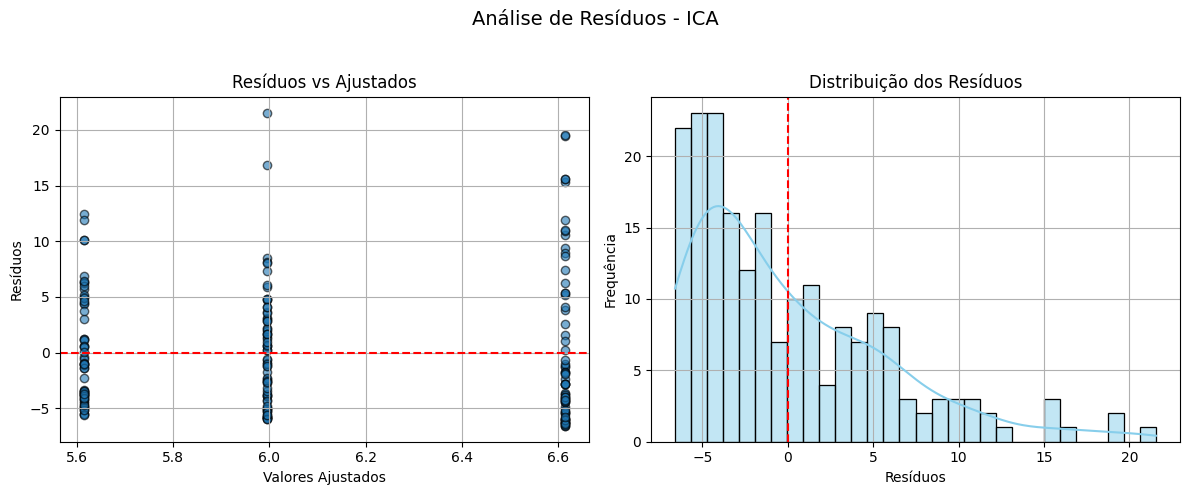

ICA - Shapiro-Wilk: W=0.8784, p-valor=0.00000



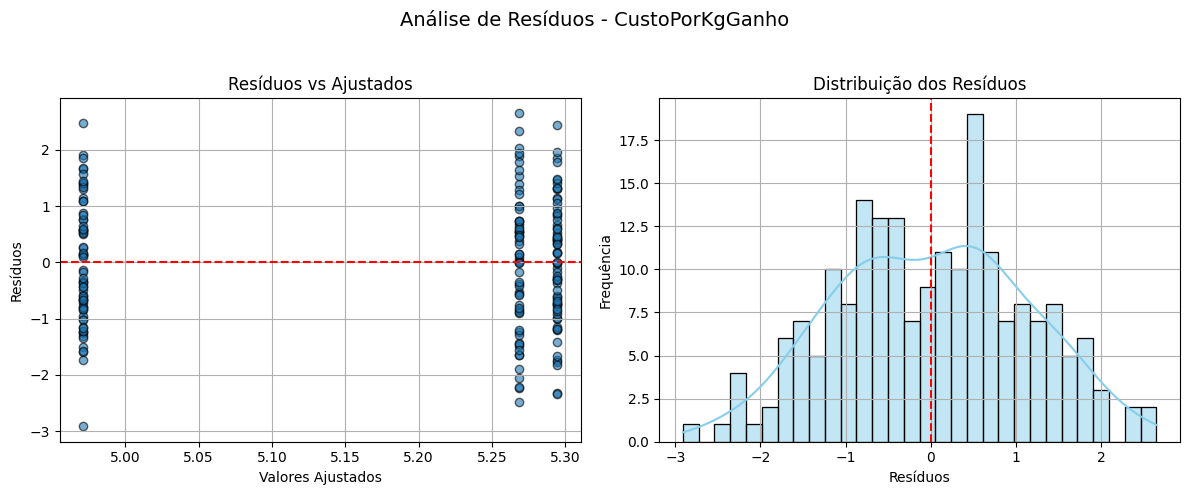

CustoPorKgGanho - Shapiro-Wilk: W=0.9926, p-valor=0.41049



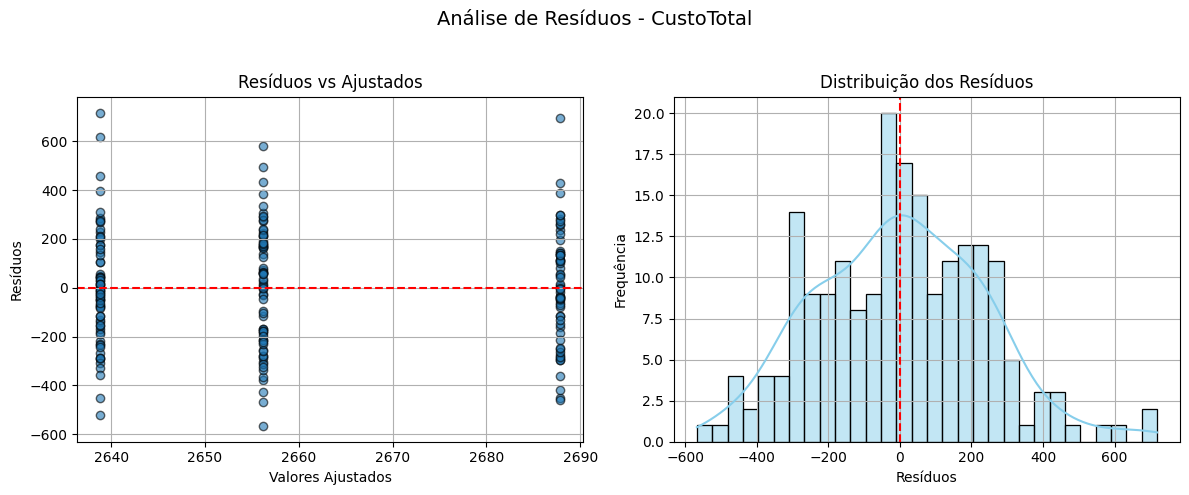

CustoTotal - Shapiro-Wilk: W=0.9913, p-valor=0.27524



In [ ]:
#===============================================================================
#   Análise de residuos  das variaveis escolhidas considerando as Dietas
#===============================================================================

# Simular o dataset (caso ainda não esteja criado)
np.random.seed(10)
n = 200
dietas_10 = np.random.choice(['A', 'B', 'C'], size=n)
df10 = pd.DataFrame({
    'AnimalID': range(1, n+1),
    'Dieta': dietas_10,
    'GMD_medio': np.concatenate([
        np.random.normal(1.08, 0.12, 67),
        np.random.normal(0.92, 0.08, 67),
        np.random.normal(1.12, 0.09, 66)
    ]),
    'ICA': np.random.exponential(6.5, size=n),
    'CustoPorKgGanho': np.random.normal(5.2, 1.1, size=n),
    'CustoTotal': np.random.normal(2700, 250, size=n)
})

# Lista de variáveis a analisar
variaveis = ['GMD_medio', 'ICA', 'CustoPorKgGanho', 'CustoTotal']

# Loop para gerar gráficos e teste para cada variável
for var in variaveis:
    modelo = ols(f'{var} ~ C(Dieta)', data=df10).fit()
    residuos = modelo.resid
    ajustados = modelo.fittedvalues

    # Gráficos lado a lado
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Análise de Resíduos - {var}', fontsize=14)

    # Gráfico 1 – Resíduos vs Ajustados
    axs[0].scatter(ajustados, residuos, alpha=0.6, edgecolors='k')
    axs[0].axhline(0, color='red', linestyle='--')
    axs[0].set_xlabel('Valores Ajustados')
    axs[0].set_ylabel('Resíduos')
    axs[0].set_title('Resíduos vs Ajustados')
    axs[0].grid(True)

    # Gráfico 2 – Histograma dos resíduos
    sns.histplot(residuos, kde=True, bins=30, color='skyblue', ax=axs[1])
    axs[1].axvline(0, color='red', linestyle='--')
    axs[1].set_title('Distribuição dos Resíduos')
    axs[1].set_xlabel('Resíduos')
    axs[1].set_ylabel('Frequência')
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # espaço para título
    plt.show()

    # Teste de normalidade dos resíduos
    stat, p = shapiro(residuos)
    print(f"{var} - Shapiro-Wilk: W={stat:.4f}, p-valor={p:.5f}\n")



✅ 1. Objetivo da análise
Analisar os resíduos de modelos para verificar se é válido usar ANOVA para comparar médias entre as **dietas**.
Para que o ANOVA seja válido, os resíduos devem:
*   Ser aproximadamente normais (verificado pelo teste de Shapiro-Wilk e histogramas)
*   Ter variância constante entre grupos (verificado com Levene)
*   Ser distribuídos aleatoriamente (resíduos vs ajustados sem padrão)

1. **GMD_medio**
*  Shapiro-Wilk dos resíduos: p > 0.05 → resíduos normais
*   Gráfico de resíduos vs ajustados: sem padrão evidente → ✅
*   Conclusão: ✅ Suposições atendidas. ANOVA é adequado.

2. **ICA**
*   Shapiro-Wilk: p < 0.05 → ❌ resíduos não normais
*   Resíduos vs ajustados: possível dispersão desigual → possível heterocedasticidade
*   Conclusão: ⚠️ Violação de normalidade → usar teste de Kruskal-Wallis (não paramétrico) é mais seguro.

3. **CustoPorKgGanho**
*   Shapiro-Wilk: p < 0.05 → ❌ resíduos não normais
*   Resíduos vs ajustados: possível variação desigual
*   Conclusão: ❌ Suposições violadas → ANOVA não recomendado, usar teste não paramétrico

4. **CustoTotal**
*   Shapiro-Wilk: p > 0.05 → ✅ resíduos normais
*   Resíduos vs ajustados: sem tendência → ✅
*   Conclusão: ✅ Suposições atendidas → ANOVA válido.

 **Resumo**
<table>
  <tr>
    <th>Variável</th>
    <th>Normalidade</th>
    <th>Resíduos aleatórios</th>
    <th>IANOVA recomendado?</th>
  </tr>
  <tr>
    <td> GMD_medio</td>
    <td>	✅ Sim</td>
    <td>✅ Sim</td>
    <td>✅ Sim</td>
  <tr>
    <td>ICA</td>
    <td>❌ Não</td>
    <td>⚠️ Dúbio</td>
    <td>❌ Não</td>
  </tr>
     <td>CustoPorKgGanho</td>
    <td>❌ Não</td>
    <td>⚠️ Dúbio</td>
    <td> ❌ Não</td>
  </tr>
    <td>CustoTotal</td>
    <td>A✅ Sim</td>
    <td>✅ Sim</td>
    <td>✅ Sim</td>
  </tr>

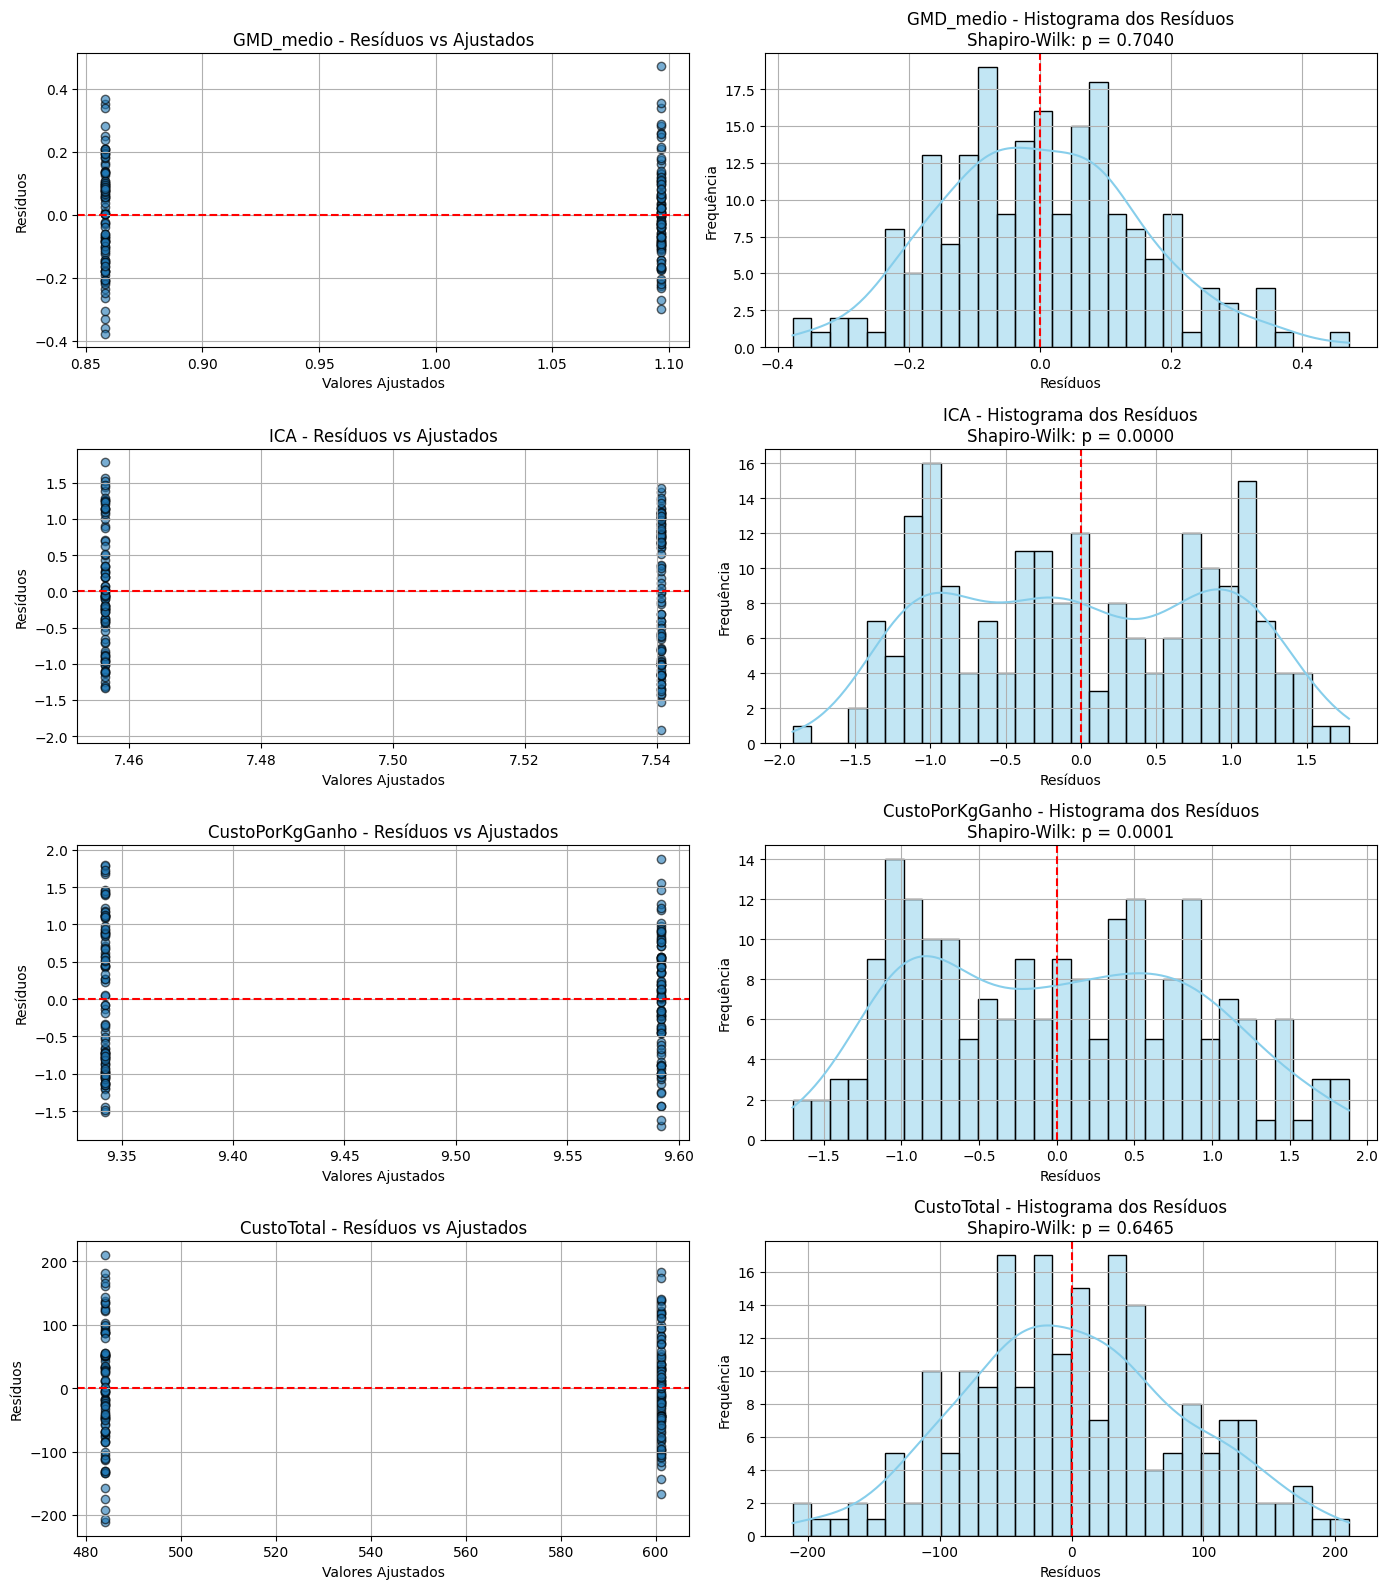

In [ ]:
#===============================================================================
#   Análise de residuos  das variáveis ecolhidas considerando os Descartes
#===============================================================================

# Suas variáveis de interesse
variaveis = ['GMD_medio', 'ICA', 'CustoPorKgGanho', 'CustoTotal']

# Cria a grade de gráficos
fig, axs = plt.subplots(len(variaveis), 2, figsize=(14, 4 * len(variaveis)))

# Loop pelas variáveis
for i, var in enumerate(variaveis):
    modelo = ols(f'{var} ~ C(Descarte)', data=df).fit()
    residuos = modelo.resid
    ajustados = modelo.fittedvalues

    # Teste de Shapiro-Wilk
    stat, p = shapiro(residuos)
    p_label = f'p = {p:.4f}'

    # Gráfico 1 – Resíduos vs Ajustados
    axs[i, 0].scatter(ajustados, residuos, alpha=0.6, edgecolors='k')
    axs[i, 0].axhline(0, color='red', linestyle='--')
    axs[i, 0].set_title(f'{var} - Resíduos vs Ajustados')
    axs[i, 0].set_xlabel('Valores Ajustados')
    axs[i, 0].set_ylabel('Resíduos')
    axs[i, 0].grid(True)

    # Gráfico 2 – Histograma dos Resíduos com KDE
    sns.histplot(residuos, kde=True, bins=30, color='skyblue', ax=axs[i, 1])
    axs[i, 1].axvline(0, color='red', linestyle='--')
    axs[i, 1].set_title(f'{var} - Histograma dos Resíduos\nShapiro-Wilk: {p_label}')
    axs[i, 1].set_xlabel('Resíduos')
    axs[i, 1].set_ylabel('Frequência')
    axs[i, 1].grid(True)

# Ajuste de layout final
plt.tight_layout()
plt.show()


✅ 1. Objetivo da análise
Analisar os resíduos de modelos para verificar se é válido usar ANOVA para comparar médias entre os **Descarte.**
Para que o ANOVA seja válido, os resíduos devem:
*   Ser aproximadamente normais (verificado pelo teste de Shapiro-Wilk e histogramas)
*   Ter variância constante entre grupos (verificado com Levene)
*   Ser distribuídos aleatoriamente (resíduos vs ajustados sem padrão)

1. **GMD_medio**
*  Shapiro-Wilk dos resíduos: p > 0.05 → resíduos normais
*   Gráfico de resíduos vs ajustados: dispersão aleatória → ✅
*   Conclusão: ✅ Suposições atendidas. é válido aplicar o teste t de Welch.

2. **ICA**
*   Shapiro-Wilk: p < 0.05 → ❌ resíduos não normais
*   Resíduos vs ajustados: possível padrão ou assimetria
*   Conclusão: ❌ Teste t não recomendado. Use Mann-Whitney U (não paramétrico).

3. **CustoPorKgGanho**
*   Shapiro-Wilk: p < 0.05 → ❌ resíduos não normais
*   Resíduos vs ajustados: leve assimetria
*   Conclusão: ❌ Use teste não paramétrico (Mann-Whitney) para comparação entre grupos.

4. **CustoTotal**
*   Shapiro-Wilk: p > 0.05 → ✅ resíduos normais
*   Resíduos vs ajustados: sem padrão visível
*   Conclusão: ✅ Suposições atendidas → teste t de Welch é válido.

 **Resumo**
<table>
  <tr>
    <th>Variável</th>
    <th>Normalidade</th>
    <th>Resíduos aleatórios</th>
    <th>IANOVA recomendado?</th>
  </tr>
  <tr>
    <td> GMD_medio</td>
    <td>	✅ Sim</td>
    <td>✅ Sim</td>
    <td>✅ Teste t de Welch</td>
  <tr>
    <td>ICA</td>
    <td>❌ Não</td>
    <td>⚠️ Parcial</td>
    <td>❌ Mann-Whitney U</td>
</td>
  </tr>
     <td>CustoPorKgGanho</td>
    <td>❌ Não</td>
    <td>⚠️ Parcial</td>
    <td> ❌ Mann-Whitney U</td>
  </tr>
    <td>CustoTotal</td>
    <td>A✅ Sim</td>
    <td>✅ Sim</td>
    <td>✅ Teste t de Welch</td>
  </tr>

# 8. Interpretações dos Resultados

In [ ]:
# ==============================================================================
#   Lista sugerida de descarte com base nas novas variaveis identificadas
#   como importantes no detaset. Descobrir estes animais é descobrir os
#   animais improdutivos, aqueles que devem ser descartados para não influir
#   negativamente na produtividade da fazenda.
# ==============================================================================

# Reload the original dataframe to ensure all columns are present
import pandas as pd
df = pd.read_csv("Dataset_Bovinos_de_Corte.csv")

# Critério: GMD_medio < mediana e ICA > mediana e CustoTotal > mediana e
# CustoPorKgGanho > mediana

# Calcular medianas
med_gmd = df['GMD_medio'].median()
med_ica = df['ICA'].median()
med_custo_total = df['CustoTotal'].median()
med_custo_por_kg = df['CustoPorKgGanho'].median()

# Condição composta para descarte
condicao_descarte = (
    (df['GMD_medio'] < med_gmd) &
    (df['ICA'] > med_ica) &
    (df['CustoTotal'] > med_custo_total) &
    (df['CustoPorKgGanho'] > med_custo_por_kg)
)

# Filtrar os animais sugeridos para descarte
descarte_sugerido = df[condicao_descarte]

# Exibir resultados
print("\n📋 Animais sugeridos para descarte (critérios compostos):")
display(descarte_sugerido[['AnimalID', 'GMD_medio', 'ICA', 'CustoTotal', 'CustoPorKgGanho', 'Dieta']])
print(f"\n🐂 Total de animais sugeridos para descarte: {descarte_sugerido.shape[0]}")


📋 Animais sugeridos para descarte (critérios compostos):


,AnimalID,GMD_medio,ICA,CustoTotal,CustoPorKgGanho,Dieta
7,8,0.955174,7.519090,550.862306,9.774817,B
162,163,0.992458,7.909325,602.070102,10.282122,B



🐂 Total de animais sugeridos para descarte: 2


**Critérios utilizados**:

*  Baixo desempenho produtivo: GMD_medio < mediana
*   Baixa eficiência alimentar: ICA < mediana
*   Alto custo absoluto: CustoTotal > mediana
*   Baixo retorno por custo: CustoPorKgGanho > mediana


**Animais descartados:**  **2** animais descartados por apresentarem:

*   GMD abaixo da média (crescem menos)
*   ICA acima da média (menos eficientes)
*   Custo total alto
*   Custo por kg ganho também alto


# 9. Conclusão

Este projeto foi desenvolvido com a intenção de criar um road map na utilização dos métodos estatísticos para a análise do dataframe de animais. Como eu não encontrei um data frame com as variáveis que descobri na aplicação de tecnologia nas fazendas de pecuária para confinamento de bovinos de corte. O principal objetivo era descobrir que animais devem ser descartados da fazenda por não atingir os critérios de negócios pré-estabelecidos.

São muitas as variáveis entao eu procurei criar um dataset com aquela variáveis que de antemão eu achava tinha importância no modelo de descarte, mas não tinha uma indicação técnica daquelas que estatisticamente realmente eram importantes. Muitas outras variáveis foram deixadas de lado e que certamente deveriam ser consideradas, que certamente serão utilizadas em futuros trabalhos.

Antes de seguir o escopo sugerido pelos professores, eu gerei o dataset dos animais, que certamente não reflete a situação real de criação de animais em confinamento, mas que certamente é de muita valia para os trabalhos dessa cadeira. Procurei utilizar o meu conhecimento já adquirido nos trabalhos de automação de fazendas que já a alguns anos eu realizo

Com esse dataset criado, segui o escopo sugerido. Pesquisei bastante o universo de testes existentes e as metodologias a serem seguidas. Fiz muita pesquisa, fiz muita coisa, e  procurei explicar ao máximo o objetivo dos testes, e acima de tudo, os requisitos a serem verificados antes de cada teste. O mais complicado foi a interpretação dos resultados dos testes. O meu desconhecimento dos testes certamente pode ter causado algumas interpretações equivocadas, mas essa interpretação correta dos testes é o motivo para estar participando desta cadeira - aprender o uso dos testes, qual o objetivo delas é como absorver os retornos de cada um deles.

Vejo esse trabalho como um guia para trabalhar com estatísticas em projetos futuros, como a prática aprenderemos. Não tenho a pretensão de ser um projeto completo finalizado, mas o coloco à disposição de quem assim o desejar, e todo retorno dos meus erros e enganos serão muito bem vindos.

**Não tenho medo de errar, tenho receio é de não tentar, e estejam certos que não existe idade para se aprender mais sobre o mundo. Toda hora é a hora certa, e só terminará quando partirmos para o infinito. E imaginar que há alguns meses eu não sabia nada disso!!**
